## Imports and functions

In [1]:
# -------------------------------------------------------------------
# 1) Standard library and environment utilities
# -------------------------------------------------------------------
import os
from datetime import datetime
from math import floor, log

# -------------------------------------------------------------------
# 2) Data / numerical analysis stack
# -------------------------------------------------------------------
import numpy as np
import pandas as pd

# -------------------------------------------------------------------
# 3) Plotting and visualization
# -------------------------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
from pylab import rcParams

# -------------------------------------------------------------------
# 4) Time series and statistics
# -------------------------------------------------------------------
from scipy import signal
from scipy.stats import norm, pearsonr, rankdata
from statsmodels.tsa import seasonal
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import adfuller, ccf, grangercausalitytests

# -------------------------------------------------------------------
# 5) Machine learning and preprocessing
# -------------------------------------------------------------------
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_absolute_percentage_error, mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

# -------------------------------------------------------------------
# 6) BigQuery client dependencies (kept for compatibility with existing workflow)
# -------------------------------------------------------------------
# from google.cloud import bigquery, bigquery_storage
from pandas_gbq import to_gbq

# -------------------------------------------------------------------
# 7) Project utilities: move reusable helper functions to analysis_utils.py
# -------------------------------------------------------------------
from analysis_utils import (
    append_csv_to_dataframe,
    adjusted_r2,
    bic,
    ccf_funct,
    cross_correlate,
    detrender,
    dual_plot_corr,
    evaluate_model,
    forward_fill_increment,
    lagged_corr_plot,
    lin_model,
    plot_ccf_2,
    robust_r2_score,
    roll_apply_max_ccf,
    series_rel_plot,
    twinplot,
    LinearModelClass,
)

# Notebook plotting defaults
rcParams['figure.figsize'] = 12, 5

# Common plotting color scheme
color1 = 'black'
color2 = 'grey'
color3 = '#ffcc00'
f = 12 * 1e6

### Intro

In [2]:
directory_path = "C:/Users/illoi/Escritorio-2/00 - RETAIL INSIGHTS & ANALYTICS/01 - MARKET ANALYSIS/Data/US - Copy"
df_file_name = 'prov2.csv'
result_df_file_name = 'prov.csv'
sep = ','

df = pd.read_csv(os.path.join(directory_path, df_file_name), sep=sep, index_col=0, parse_dates=[0])
result_df = pd.read_csv(os.path.join(directory_path, result_df_file_name), sep=sep, index_col=0, parse_dates=[0])
df.head()

,CB CCI,Household PCE,Michigan CSI,PCE Durable goods Furnishings and durable household equipment,PCE,PCEDG PCE Durable goods,PCEDGC96 Real PCE Durable goods Chain-type,PCEPI PCE Chain-type,PCEPILFE PCE Excl Food and Energy Chain-Type,Real Households Final PCE,...,Real Usable Personal Income,Personal Consumption Expenditures per capita,Real Personal Consumption Expenditures per capita,Real Personal Consumption Expenditures per household,Consumption as share of GDP,roll_Consumption as share of GDP,roll_Consumption exp as share of GDP,Retail Sales Furniture & HF corr,Y,Y_infl_adj
1992-01-01,52.5,4109.625,67.5,121.980,4084.7,495.6,NaN,62.638,63.641,1607342.5,...,25967.688136,15.954993,28.278407,75.674101,0.641935,0.642253,0.643000,3699.0,3975.607143,2874.625555
1992-02-01,50.2,4109.625,68.8,121.980,4099.5,501.3,NaN,62.797,63.814,1607342.5,...,25953.929663,16.000568,28.297801,75.783899,0.641548,0.642516,0.643143,3759.0,3992.937500,2880.907287
1992-03-01,47.3,4109.625,76.0,121.980,4117.0,491.7,NaN,62.949,63.973,1607342.5,...,25957.001921,16.059669,28.300232,75.833836,0.642662,0.642504,0.643250,3997.0,4020.301587,2890.224002
1992-04-01,56.5,4109.625,77.2,122.968,4131.5,490.0,NaN,63.119,64.183,1616605.0,...,26001.846848,16.109056,28.326169,75.937146,0.642765,0.642619,0.643333,3981.0,4051.587500,2906.447274
1992-05-01,65.1,4109.625,79.2,122.968,4158.4,501.9,NaN,63.203,64.273,1616605.0,...,25990.949403,16.202541,28.429371,76.267435,0.642879,0.642933,0.643500,4109.0,4078.626263,2919.560675


### Adding the diff columns

In [3]:
original_cols = df.columns

In [4]:
diff_df = pd.DataFrame()
pct_df = pd.DataFrame()
roll_pct_df = pd.DataFrame()

diff_df = df.diff()
pct_df = df.pct_change(fill_method=None)
roll_pct_df = df.pct_change(fill_method=None).rolling(window=12, min_periods=1, center=True).mean()

diff_df.rename(columns=dict(zip(diff_df.columns,'diff_' + diff_df.columns)), inplace=True)
pct_df.rename(columns=dict(zip(pct_df.columns,'pct_chg_' + pct_df.columns)), inplace=True)
roll_pct_df.rename(columns=dict(zip(roll_pct_df.columns,'roll_pct_chg_' + roll_pct_df.columns)), inplace=True)

df = pd.concat([df, diff_df, pct_df, roll_pct_df], axis=1)

## Economic relationships

### Economy

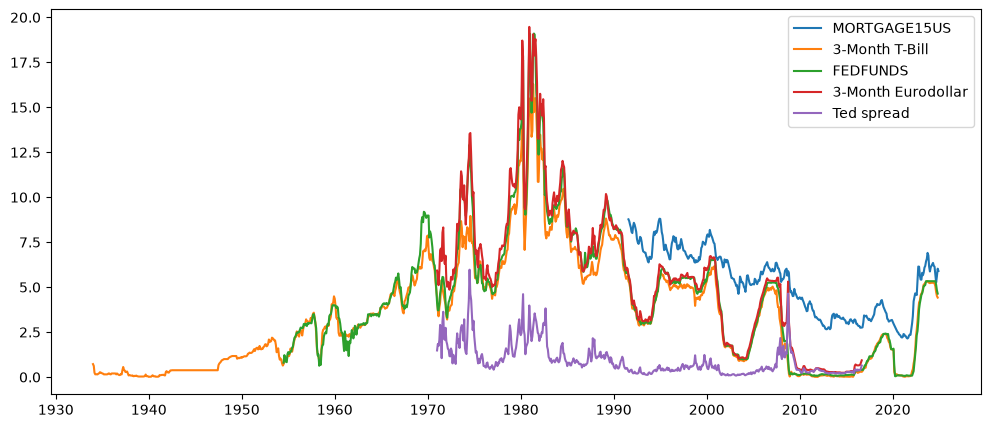

In [5]:
plt.plot(result_df['MORTGAGE15US'], label='MORTGAGE15US')
plt.plot(result_df['3-Month TB Secondary Market Rate'], label='3-Month T-Bill')
plt.plot(result_df['FEDFUNDS'], label='FEDFUNDS')
plt.plot(result_df['3-Month Eurodollar Deposit Rate'], label='3-Month Eurodollar')
plt.plot(result_df['3-Month Eurodollar Deposit Rate'] - result_df['3-Month TB Secondary Market Rate'], label='Ted spread')
plt.legend()

<Axes: >

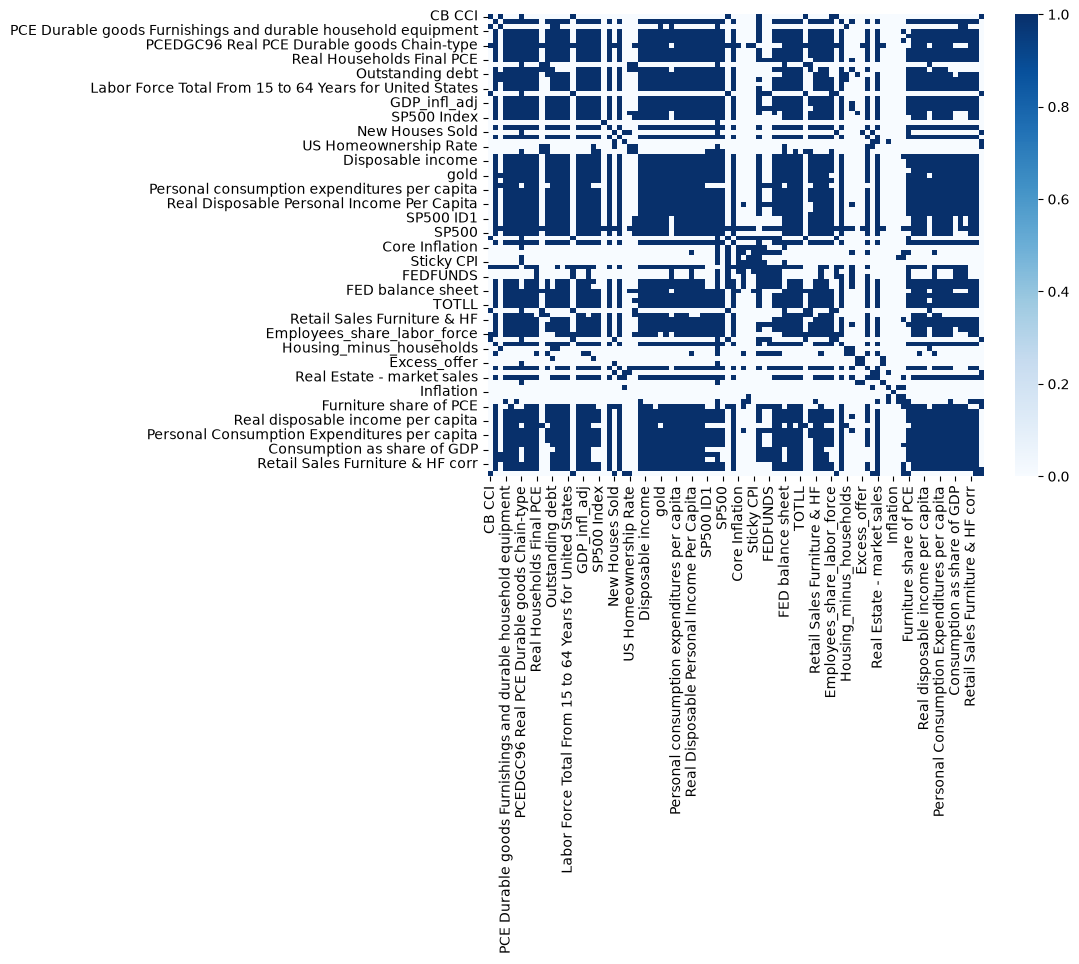

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(abs(df[original_cols].corr())>0.5, cmap='Blues', center=0.5)

<Axes: >

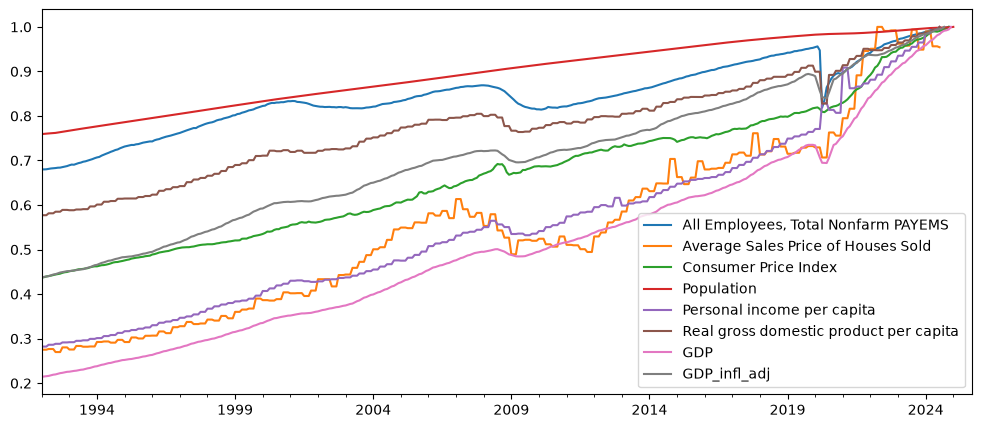

In [7]:
ec_cols = ['All Employees, Total Nonfarm PAYEMS', 
           'Average Sales Price of Houses Sold', 
           'Consumer Price Index', 
           'Population', 
           'Personal income per capita', 
           'Real gross domestic product per capita',
           'GDP',
           'GDP_infl_adj'
          ]

(df[ec_cols]/df[ec_cols].max()).plot()

<Axes: >

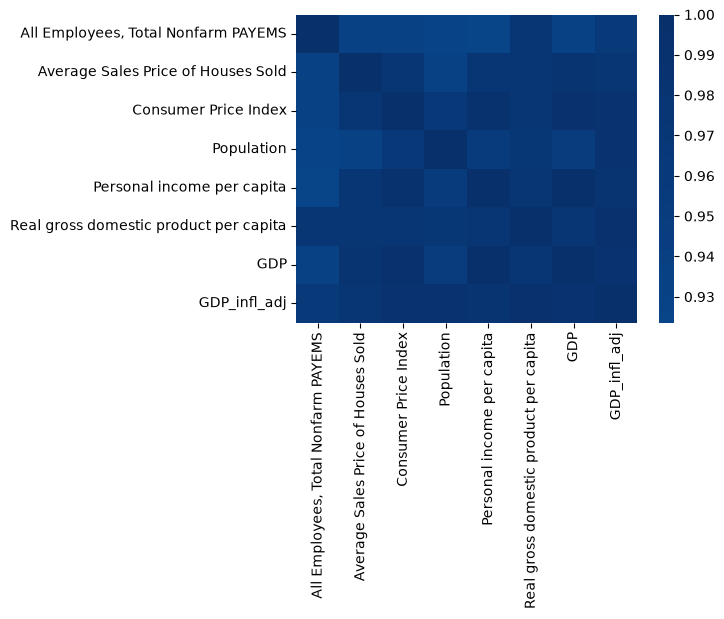

In [8]:
plt.figure(figsize=(5.5,4))
sns.heatmap(abs(df[ec_cols].corr()), cmap='Blues', center=0.5)

<Axes: >

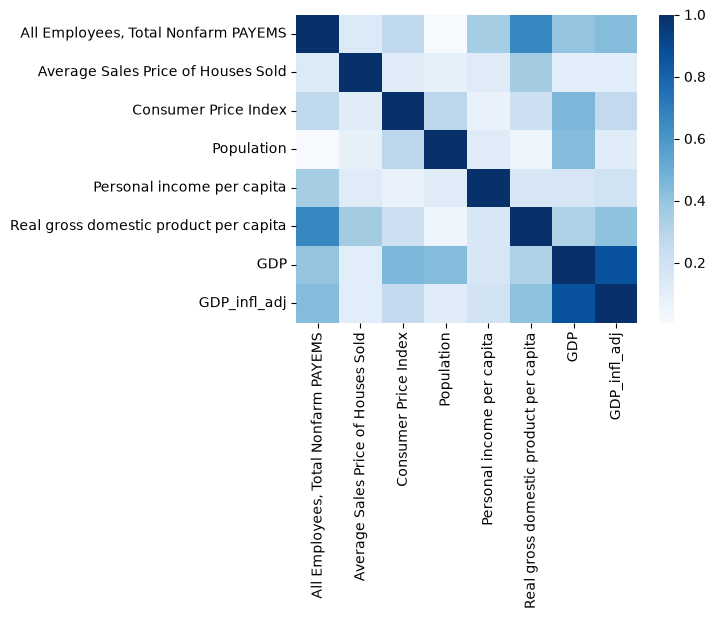

In [9]:
plt.figure(figsize=(5.5,4))
sns.heatmap(abs(df[ec_cols].diff().corr()), cmap='Blues', center=0.5)

,"roll_pct_chg_All Employees, Total Nonfarm PAYEMS",roll_pct_chg_Average Sales Price of Houses Sold,roll_pct_chg_Consumer Price Index,roll_pct_chg_Population,roll_pct_chg_Personal income per capita,roll_pct_chg_Real gross domestic product per capita,roll_pct_chg_GDP,roll_pct_chg_GDP_infl_adj
"roll_pct_chg_All Employees, Total Nonfarm PAYEMS",1.000000,0.371209,0.489707,0.079492,0.141536,0.779084,0.802424,0.781201
roll_pct_chg_Average Sales Price of Houses Sold,0.371209,1.000000,0.328828,-0.069548,0.150013,0.456961,0.565048,0.477831
roll_pct_chg_Consumer Price Index,0.489707,0.328828,1.000000,-0.223922,0.270553,0.357235,0.683546,0.343142
roll_pct_chg_Population,0.079492,-0.069548,-0.223922,1.000000,-0.169649,-0.051723,-0.082539,0.150554
roll_pct_chg_Personal income per capita,0.141536,0.150013,0.270553,-0.169649,1.000000,0.344616,0.396170,0.369134
roll_pct_chg_Real gross domestic product per capita,0.779084,0.456961,0.357235,-0.051723,0.344616,1.000000,0.837936,0.920821
roll_pct_chg_GDP,0.802424,0.565048,0.683546,-0.082539,0.396170,0.837936,1.000000,0.881481
roll_pct_chg_GDP_infl_adj,0.781201,0.477831,0.343142,0.150554,0.369134,0.920821,0.881481,1.000000


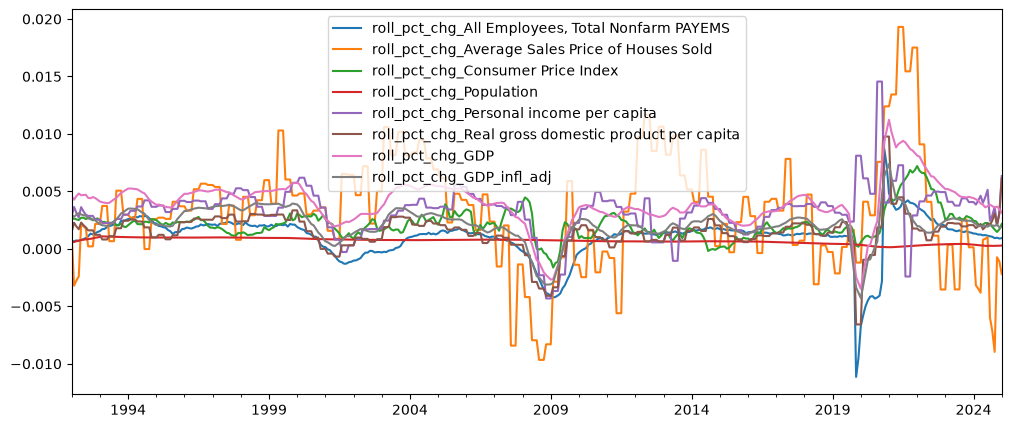

In [10]:
ec_df = df[['roll_pct_chg_' + x for x in ec_cols]].dropna()
ec_df.plot()
ec_df.corr()

<Axes: >

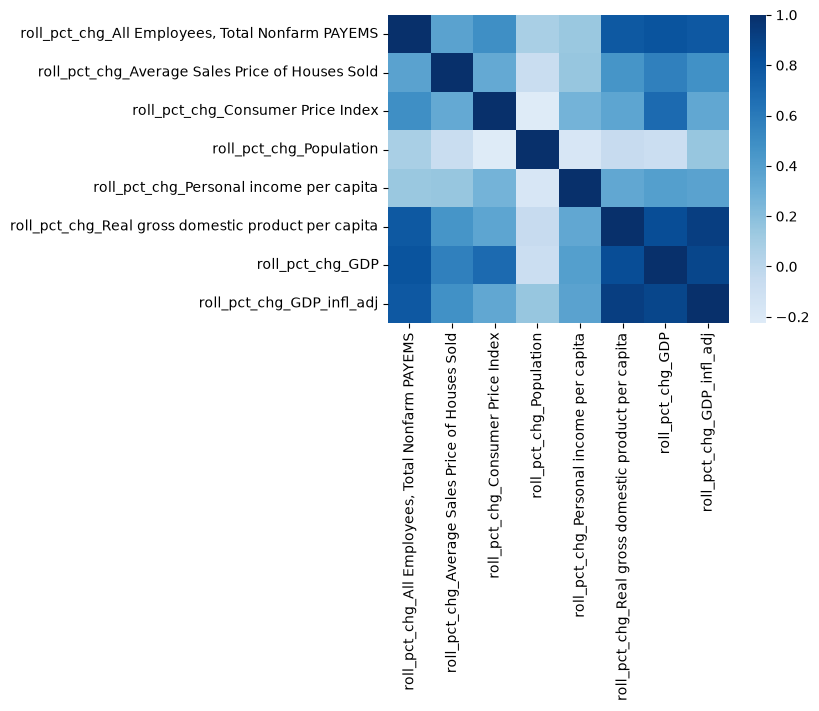

In [11]:
plt.figure(figsize=(5.5,4))
sns.heatmap(ec_df.corr(), cmap='Blues', center=0.3)

27
-0.03822099400951385


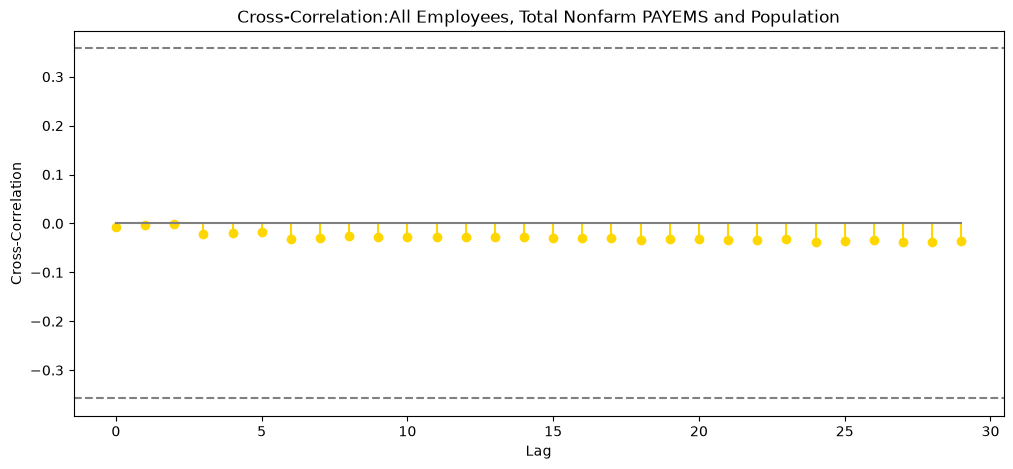

In [12]:
IR_MORT_ccf = ccf_funct(df['All Employees, Total Nonfarm PAYEMS'].diff().dropna(), df['Population'].diff().dropna(), 30)

### M2 vs inflation

3381.2
21441.8
4.67062244169589
6.341476398911629
0.7365197231511414


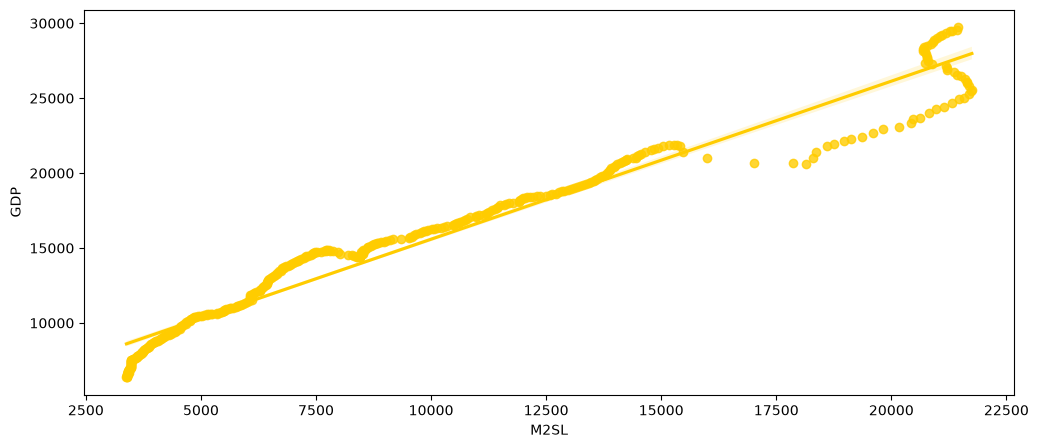

In [13]:
sns.regplot(data=df, x='M2SL', y='GDP', color=color3)

aux_df = df[['GDP', 'M2SL']].dropna()
gdp_mult_factor = (aux_df['GDP'].iloc[-1] / aux_df['GDP'].iloc[0])
M2_mult_factor = (aux_df['M2SL'].iloc[-1] / aux_df['M2SL'].iloc[0])

print(aux_df['M2SL'].iloc[0])
print(aux_df['M2SL'].iloc[-1])

print(gdp_mult_factor)
print(M2_mult_factor)
print(gdp_mult_factor / M2_mult_factor)

1.383
3.16441
4.67062244169589
6.336300721637289
0.36110606890252805


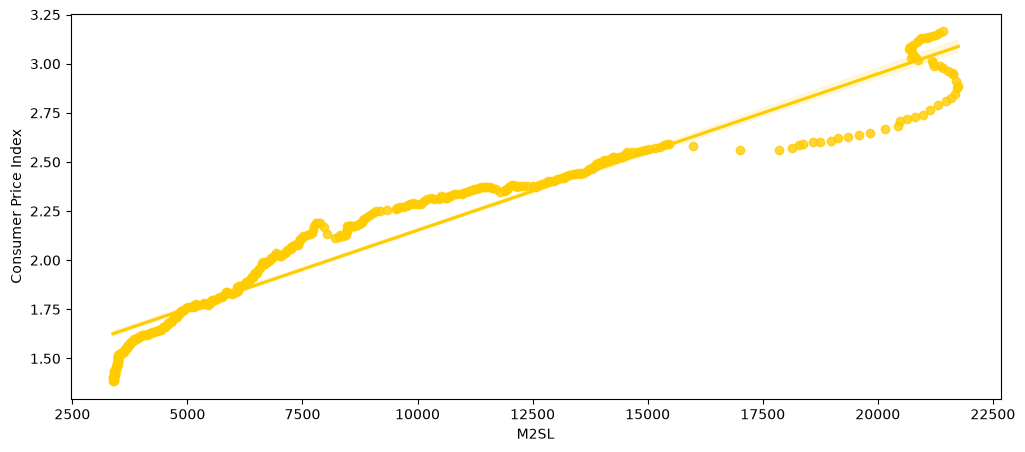

In [14]:
sns.regplot(data=df, x='M2SL', y='Consumer Price Index', color=color3)

aux_df = df[['Consumer Price Index', 'M2SL']].dropna()
cpi_mult_factor = (aux_df['Consumer Price Index'].iloc[-1] / aux_df['Consumer Price Index'].iloc[0])
M2_mult_factor = (aux_df['M2SL'].iloc[-1] / aux_df['M2SL'].iloc[0])

print(aux_df['Consumer Price Index'].iloc[0])
print(aux_df['Consumer Price Index'].iloc[-1])

print(gdp_mult_factor)
print(M2_mult_factor)
print(cpi_mult_factor / M2_mult_factor)

C:\Users\illoi\AppData\Local\Temp\ipykernel_42180\3529507468.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['year'] = df.index.year


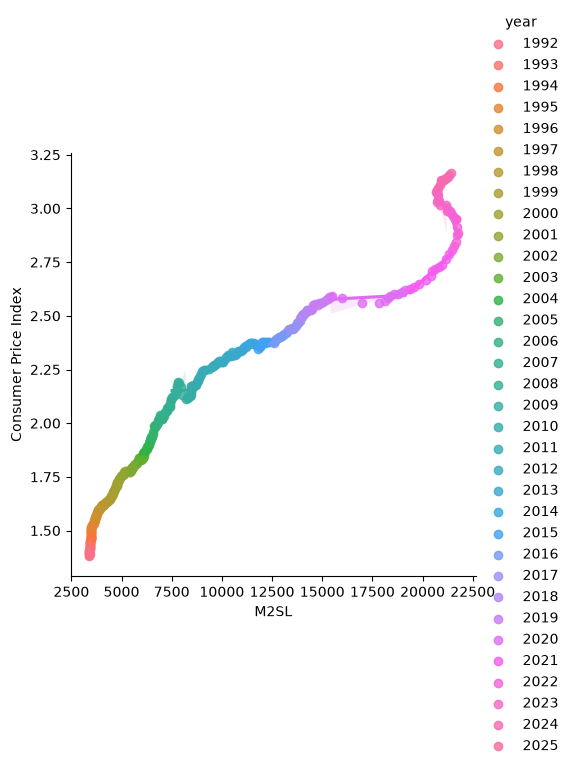

In [15]:
df['year'] = df.index.year
sns.lmplot(data=df, x='M2SL', y='Consumer Price Index', hue='year')

np.float64(0.49197510037580466)

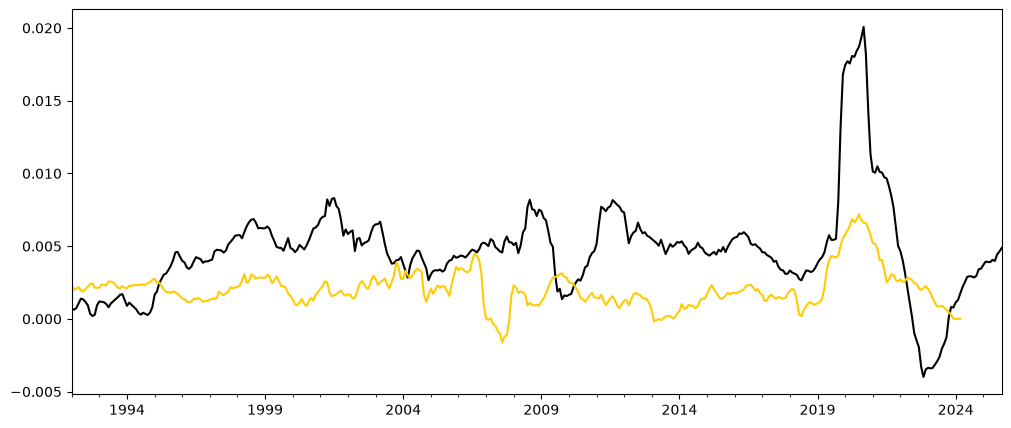

In [16]:
s1 = df['M2SL'].pct_change(fill_method=None).rolling(window=12, min_periods=1, center=True).mean()
s2 = df['Inflation'].rolling(window=12, min_periods=1, center=True).mean().shift(-18)
s1.plot(color=color1)
s2.plot(color=color3)
s1.corr(s2)

<Axes: xlabel='M2SL', ylabel='Inflation'>

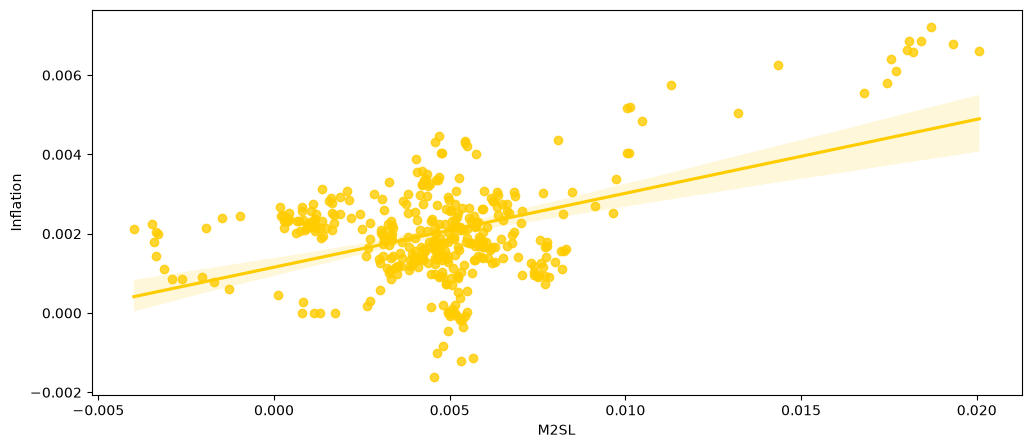

In [17]:
sns.regplot(x=s1, y=s2, color=color3)

<Axes: xlabel='roll_pct_chg_M2SL', ylabel='roll_pct_chg_Consumer Price Index'>

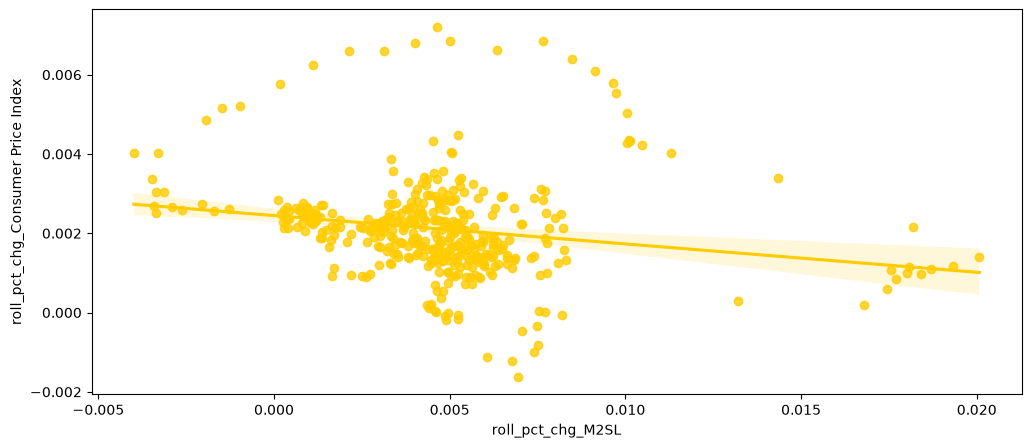

In [18]:
sns.regplot(data=df, x='roll_pct_chg_M2SL', y='roll_pct_chg_Consumer Price Index', color=color3)

### Interest rates

In [19]:
[a for a in df.columns if 'MORTG' in a]

['MORTGAGE15US',
 'MORTGAGE30US',
 'diff_MORTGAGE15US',
 'diff_MORTGAGE30US',
 'pct_chg_MORTGAGE15US',
 'pct_chg_MORTGAGE30US',
 'roll_pct_chg_MORTGAGE15US',
 'roll_pct_chg_MORTGAGE30US']

,MORTGAGE15US,MORTGAGE30US
MORTGAGE15US,1.000000,0.996992
MORTGAGE30US,0.996992,1.000000


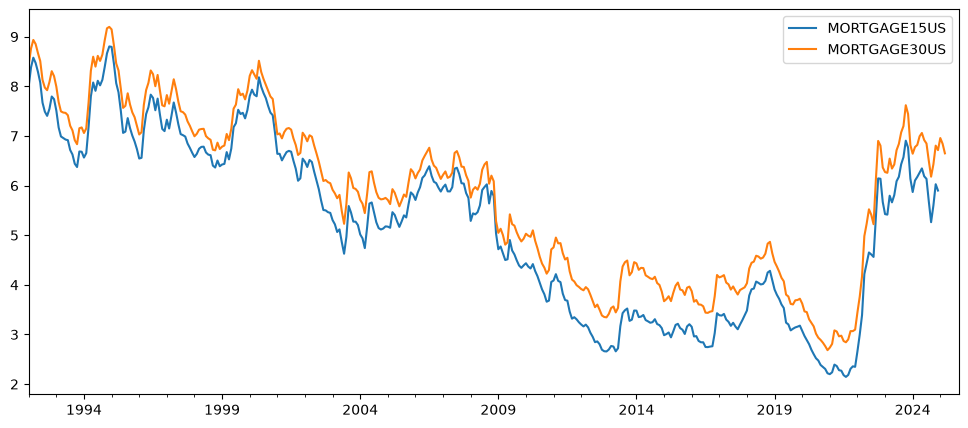

In [20]:
df[['MORTGAGE15US', 'MORTGAGE30US']].plot()
df[['MORTGAGE15US', 'MORTGAGE30US']].corr()

,3-Month Eurodollar Deposit Rate,3-Month TB Secondary Market Rate,FEDFUNDS,MORTGAGE15US
3-Month Eurodollar Deposit Rate,1.000000,0.977738,0.982913,0.864874
3-Month TB Secondary Market Rate,0.977738,1.000000,0.993991,0.850170
FEDFUNDS,0.982913,0.993991,1.000000,0.845716
MORTGAGE15US,0.864874,0.850170,0.845716,1.000000


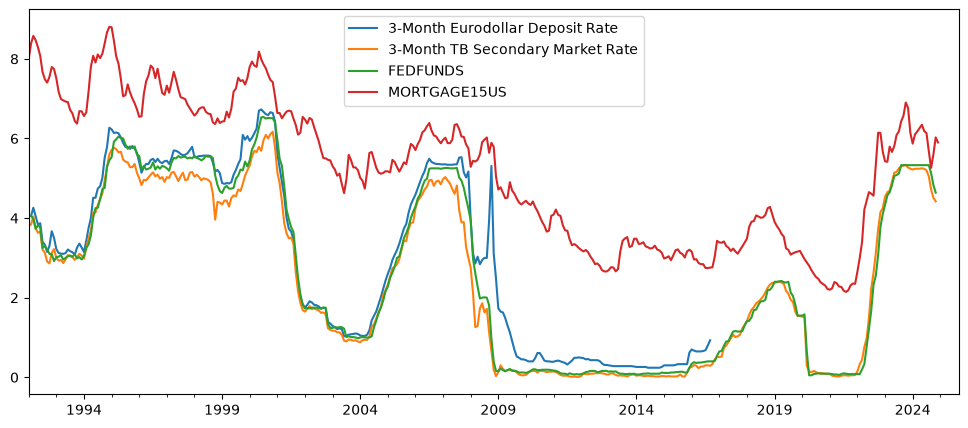

In [21]:
ir_cols = ['3-Month Eurodollar Deposit Rate', 
           '3-Month TB Secondary Market Rate', 
           'FEDFUNDS', 
           'MORTGAGE15US'
          ]

df[ir_cols].plot()
df[ir_cols].corr()

,3-Month Eurodollar Deposit Rate,3-Month TB Secondary Market Rate,FEDFUNDS,MORTGAGE15US
3-Month Eurodollar Deposit Rate,1.000000,0.921370,0.917445,0.601498
3-Month TB Secondary Market Rate,0.921370,1.000000,0.977417,0.646974
FEDFUNDS,0.917445,0.977417,1.000000,0.562804
MORTGAGE15US,0.601498,0.646974,0.562804,1.000000


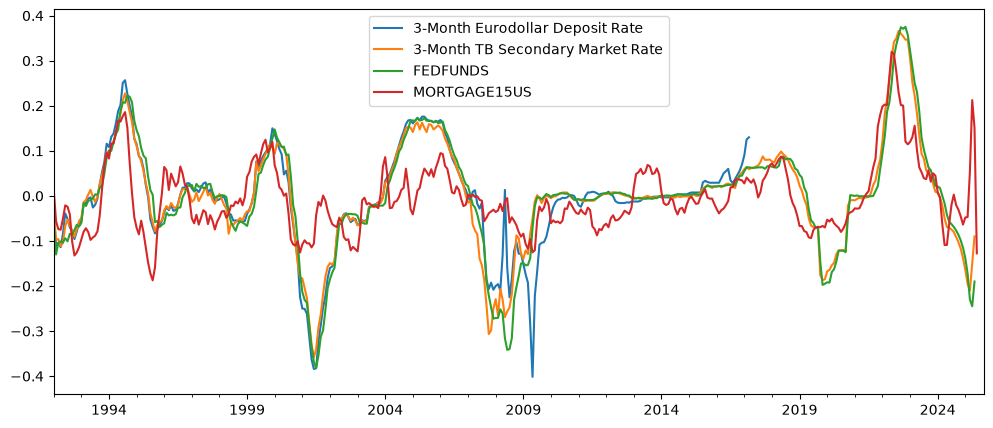

In [22]:
ir_df = df[ir_cols].diff().rolling(window=12, min_periods=1, center=True).mean()
ir_df.plot()
ir_df.corr()

PearsonRResult(statistic=np.float64(0.8457161110672576), pvalue=np.float64(3.0423079136406417e-109))


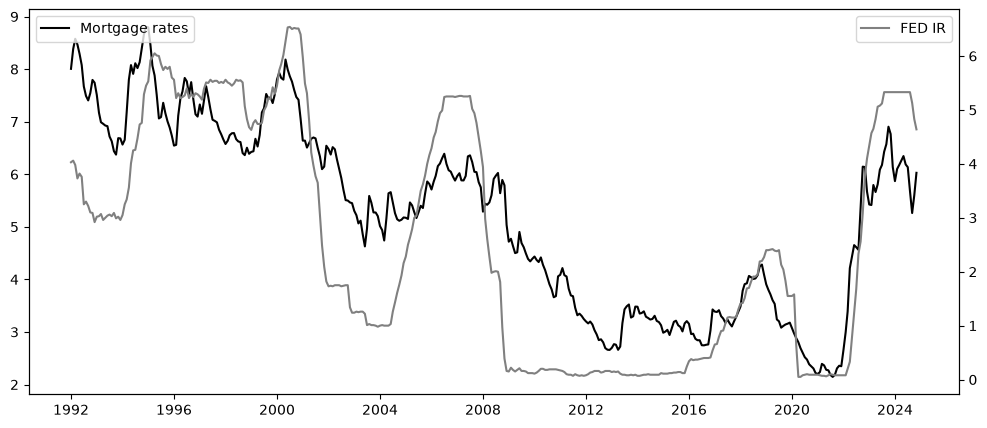

In [23]:
col1 = 'MORTGAGE15US'
col2 = 'FEDFUNDS'
aux_df =df[[col1,col2]].dropna()
plt_dict_1 = {'Mortgage rates': aux_df[col1]}
plt_dict_2 = {'FED IR': aux_df[col2]}
twinplot(plt_dict_1, plt_dict_2)

0
0.8466209855602396


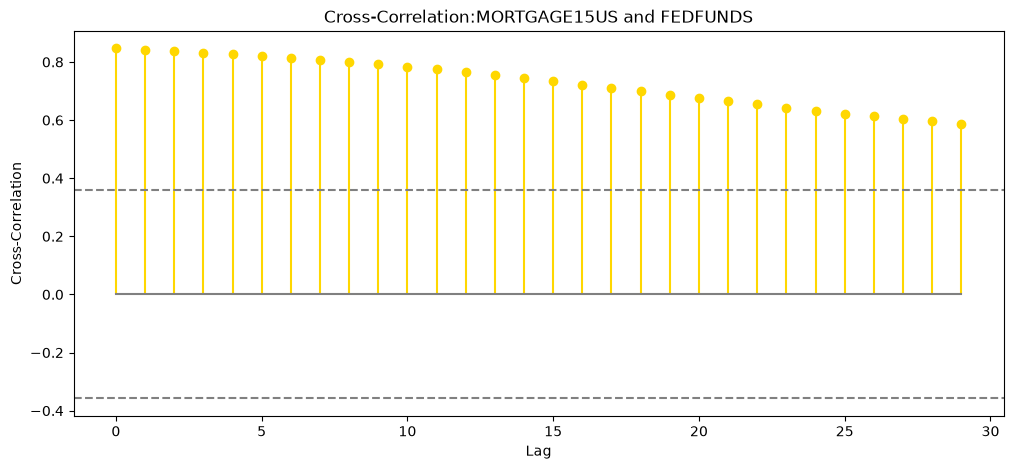

In [24]:
IR_MORT_ccf = ccf_funct(df['MORTGAGE15US'].dropna(), df['FEDFUNDS'].dropna(), 30)

PearsonRResult(statistic=np.float64(0.6044883426947903), pvalue=np.float64(1.2909988273017815e-40))


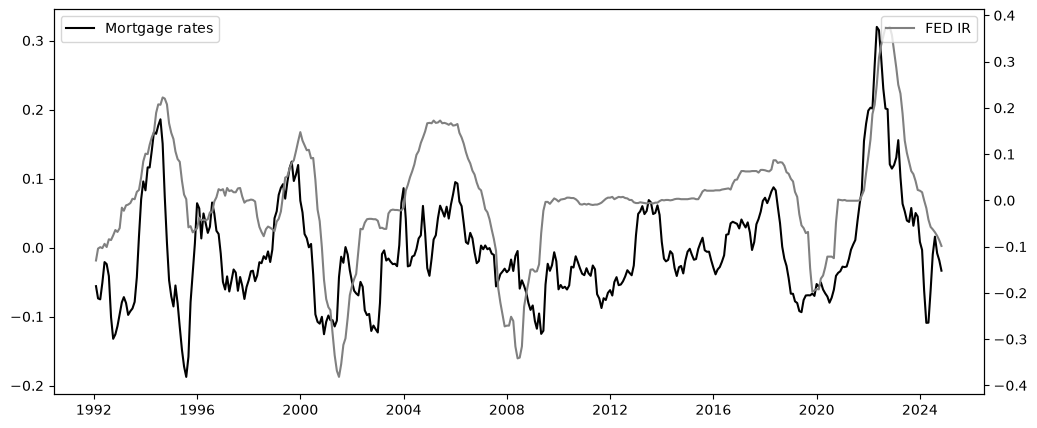

In [25]:
col1 = 'diff_MORTGAGE15US'
col2 = 'diff_FEDFUNDS'
aux_df =df[[col1,col2]].dropna()
plt_dict_1 = {'Mortgage rates': aux_df[col1].rolling(window=12, min_periods=1, center=True).mean()}
plt_dict_2 = {'FED IR': aux_df[col2].rolling(window=12, min_periods=1, center=True).mean()}
twinplot(plt_dict_1, plt_dict_2)

0
0.21077356962286833


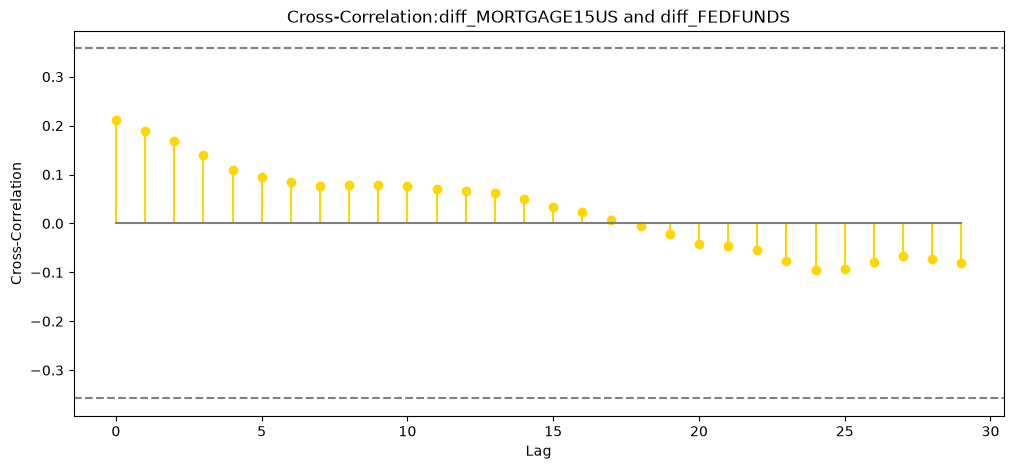

In [26]:
IR_MORT_ccf = ccf_funct(df['diff_MORTGAGE15US'].dropna(), df['diff_FEDFUNDS'].rolling(window=12, min_periods=1, center=True).mean().dropna(), 30)

0
0.160589875314647


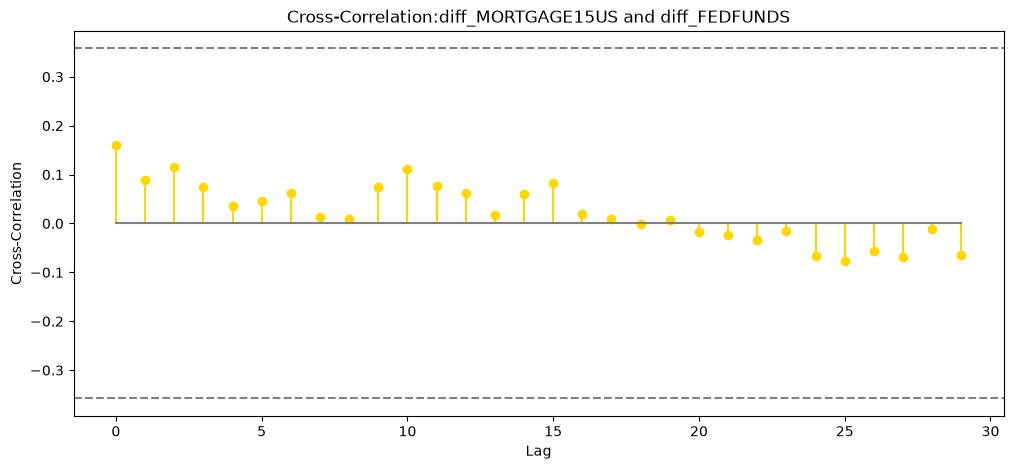

In [27]:
IR_MORT_ccf = ccf_funct(df['diff_MORTGAGE15US'].dropna(), df['diff_FEDFUNDS'].dropna(), 30)

0
0.4377021005135534


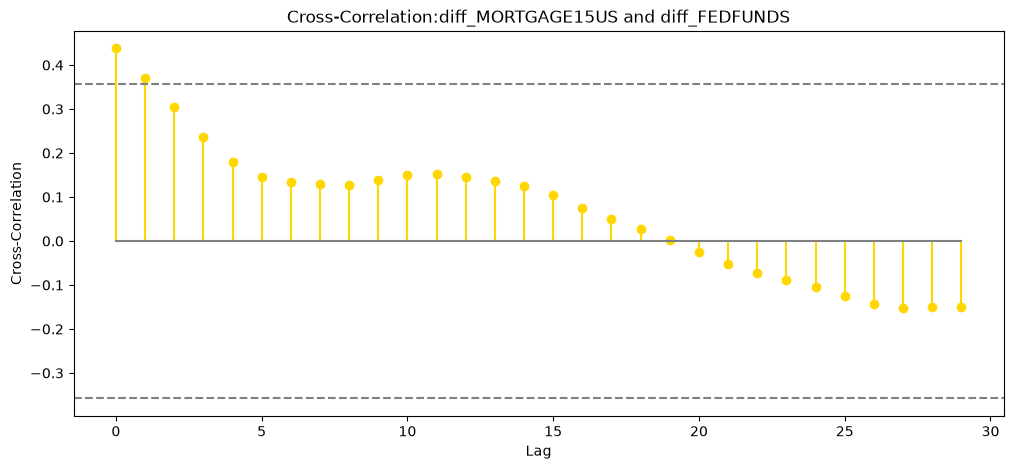

In [28]:
IR_MORT_ccf = ccf_funct(df['diff_MORTGAGE15US'].rolling(window=6, min_periods=1, center=True).mean().dropna(), 
                        df['diff_FEDFUNDS'].rolling(window=6, min_periods=1, center=True).mean().dropna(), 
                        30
                       )

PearsonRResult(statistic=np.float64(0.7924536796018864), pvalue=np.float64(1.0687664295202506e-87))


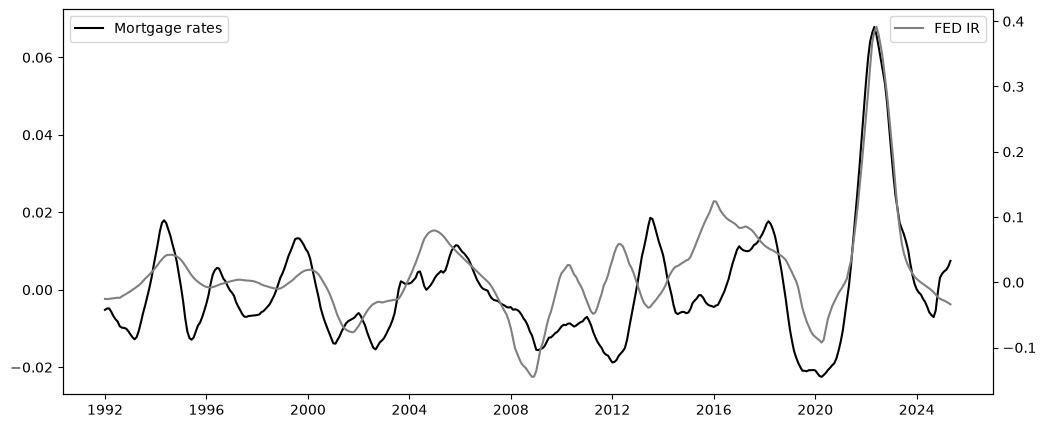

In [29]:
col1 = 'roll_pct_chg_MORTGAGE15US'
col2 = 'roll_pct_chg_FEDFUNDS'
aux_df =df[[col1,col2]].dropna()
plt_dict_1 = {'Mortgage rates': aux_df[col1].rolling(window=12, min_periods=1, center=True).mean()}
plt_dict_2 = {'FED IR': aux_df[col2].rolling(window=12, min_periods=1, center=True).mean()}
twinplot(plt_dict_1, plt_dict_2)

0
0.6945494099824322


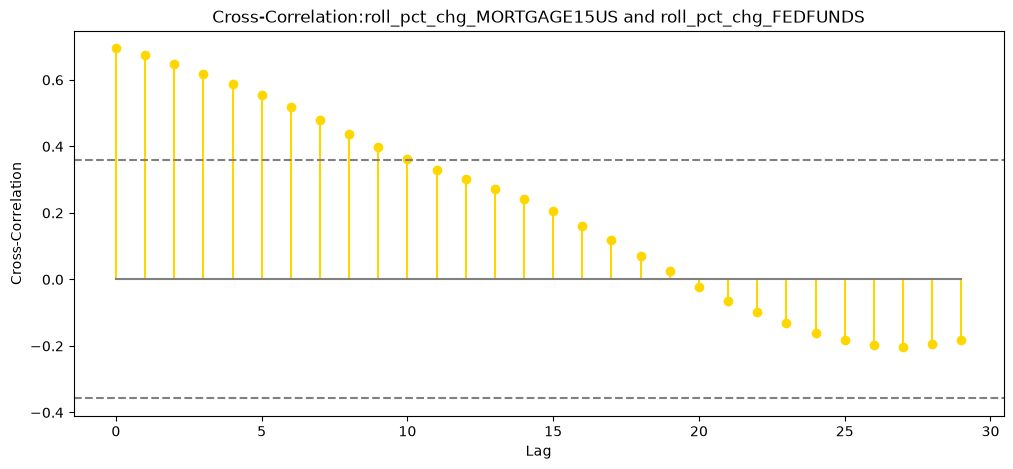

In [30]:
IR_MORT_ccf = ccf_funct(df['roll_pct_chg_MORTGAGE15US'].dropna(), df['roll_pct_chg_FEDFUNDS'].dropna(), 30)

In [31]:
[x for x in df.columns if 'FED' in x]

['FEDFUNDS',
 'FED balance sheet',
 'diff_FEDFUNDS',
 'diff_FED balance sheet',
 'pct_chg_FEDFUNDS',
 'pct_chg_FED balance sheet',
 'roll_pct_chg_FEDFUNDS',
 'roll_pct_chg_FED balance sheet']

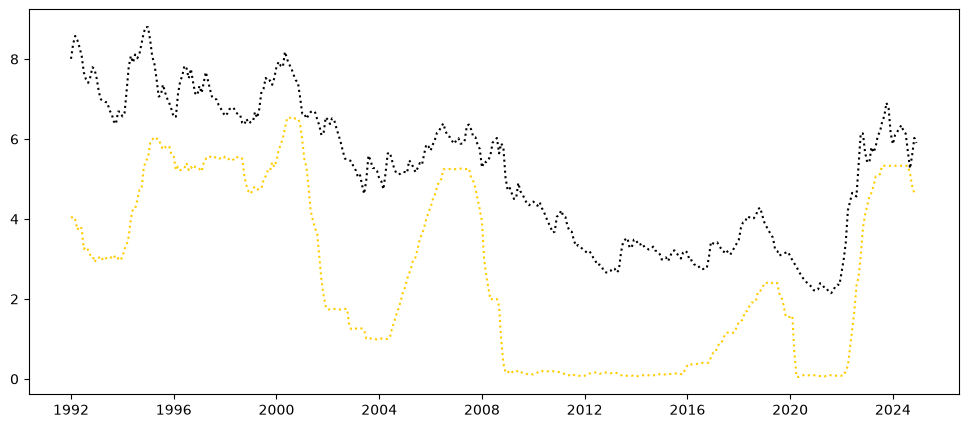

In [32]:
plt.plot(df['FEDFUNDS'], color3, label='FEDFUNDS', linestyle=':')
plt.plot(df['MORTGAGE15US'], color1, label='FEDFUNDS', linestyle=':')

np.float64(0.8457161110672576)

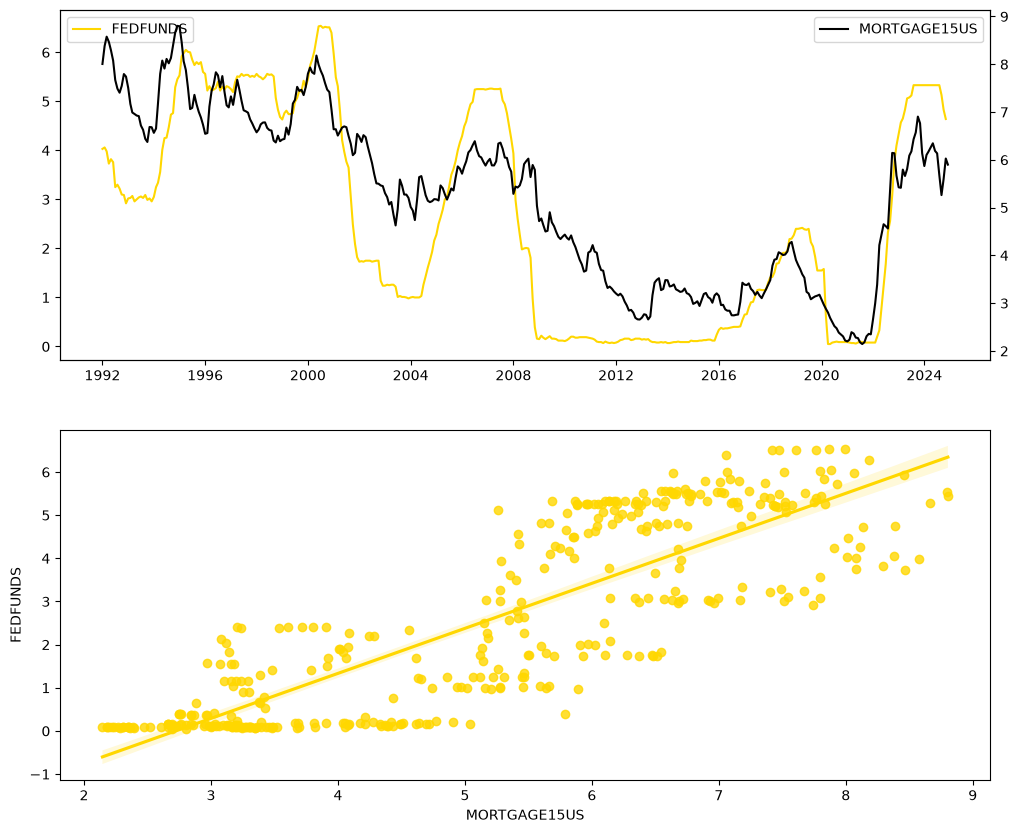

In [33]:
series_rel_plot(df['FEDFUNDS'], df['MORTGAGE15US'])

np.float64(0.694962573653807)

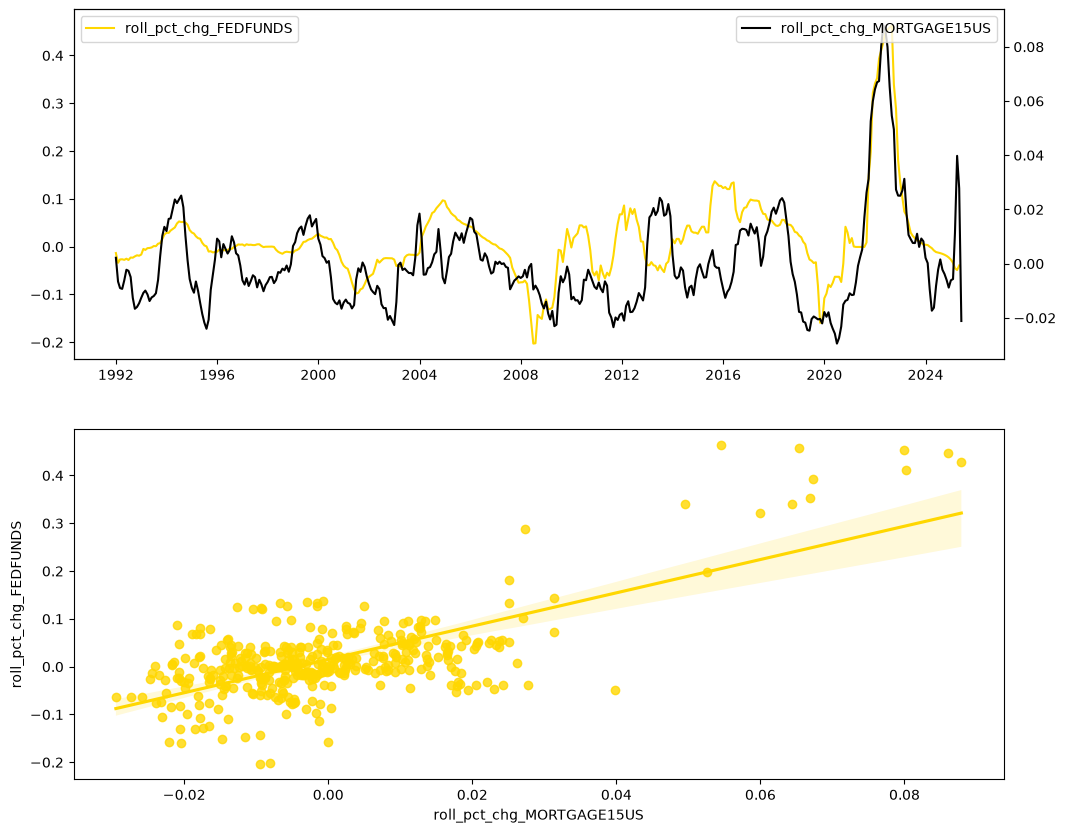

In [34]:
series_rel_plot(df['roll_pct_chg_FEDFUNDS'], df['roll_pct_chg_MORTGAGE15US'])

<Axes: >

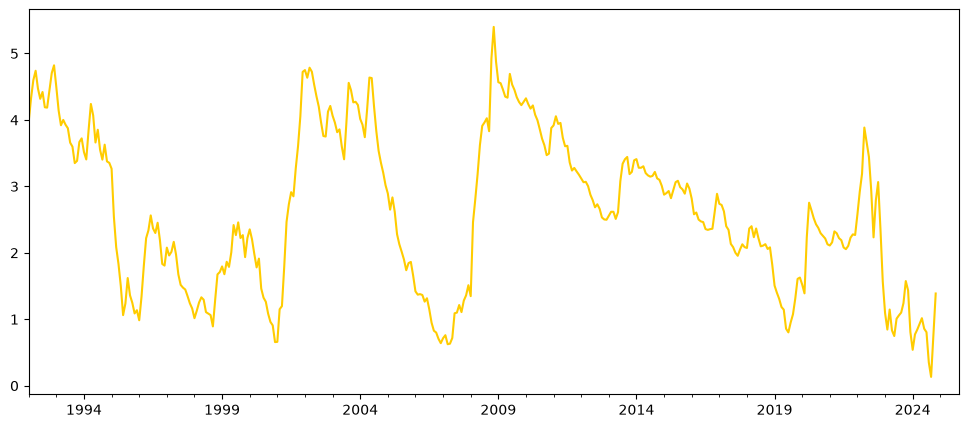

In [35]:
(df['MORTGAGE15US'] - df['FEDFUNDS']).plot(color=color3)

0
0.160589875314647


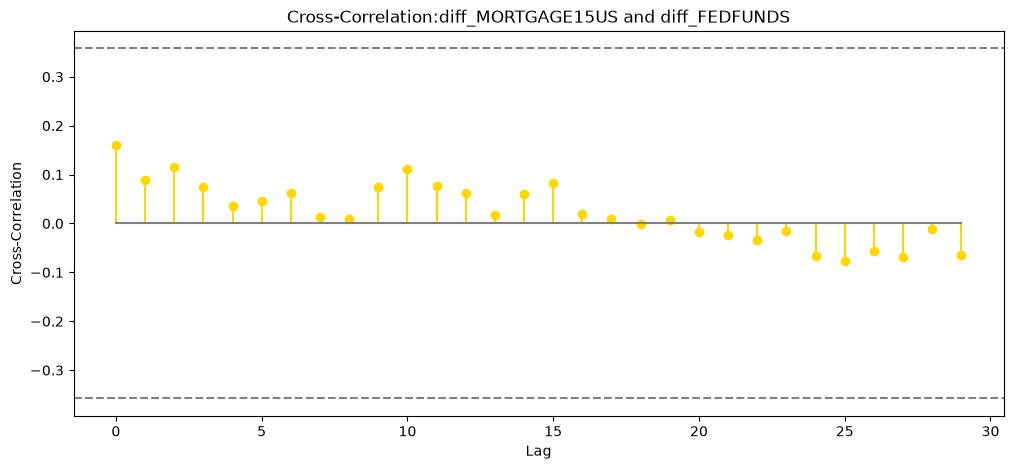

In [36]:
FEDFUNDS_MORT_ccf = ccf_funct(df['diff_MORTGAGE15US'].dropna(), df['diff_FEDFUNDS'].dropna(), 30)

0
0.6945494099824322


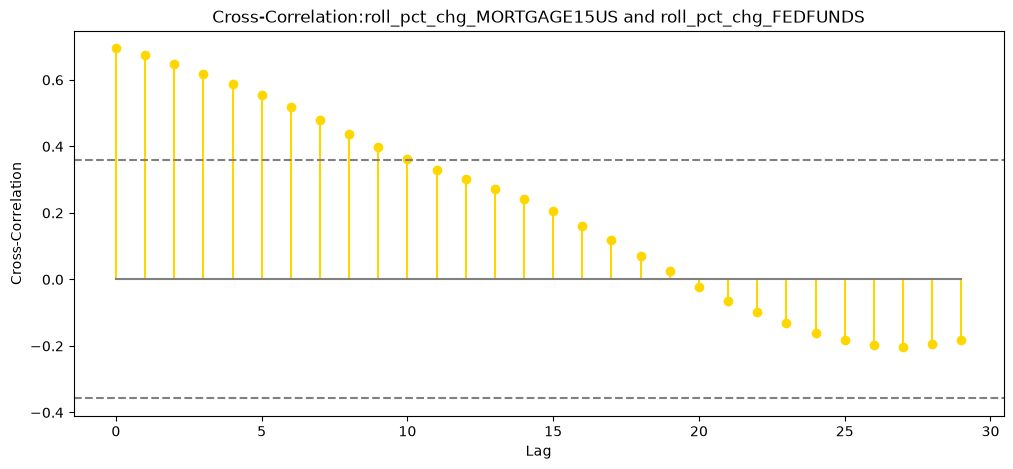

In [37]:
FEDFUNDS_MORT_ccf = ccf_funct(df['roll_pct_chg_MORTGAGE15US'].dropna(), df['roll_pct_chg_FEDFUNDS'].dropna(), 30)

### Inflation and interest rates

##### Intro

In [38]:
[x for x in original_cols if 'nflat' in x]

['Core Inflation',
 'Inflation, consumer prices',
 'Inflation',
 '12M_roll_inflation']

<Axes: >

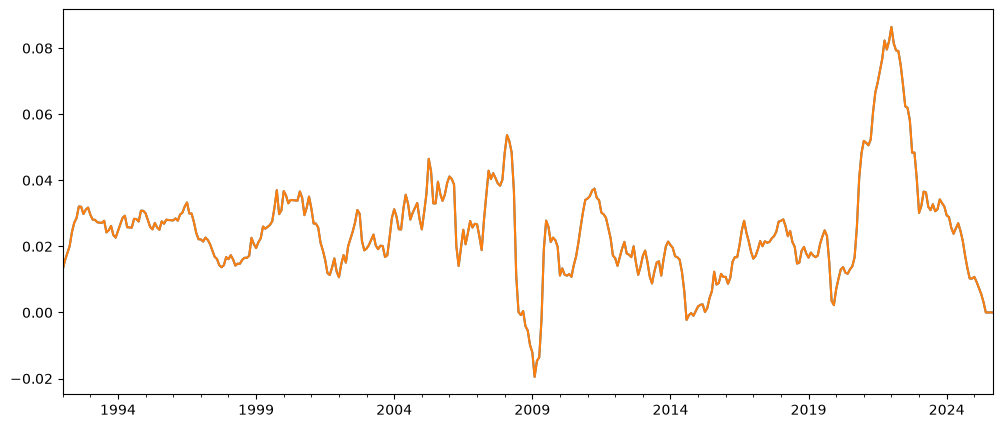

In [39]:
df['Inflation'].rolling(window=12, min_periods=1, center=True).sum().plot()
df['12M_roll_inflation'].plot()

np.float64(0.47795156892475693)

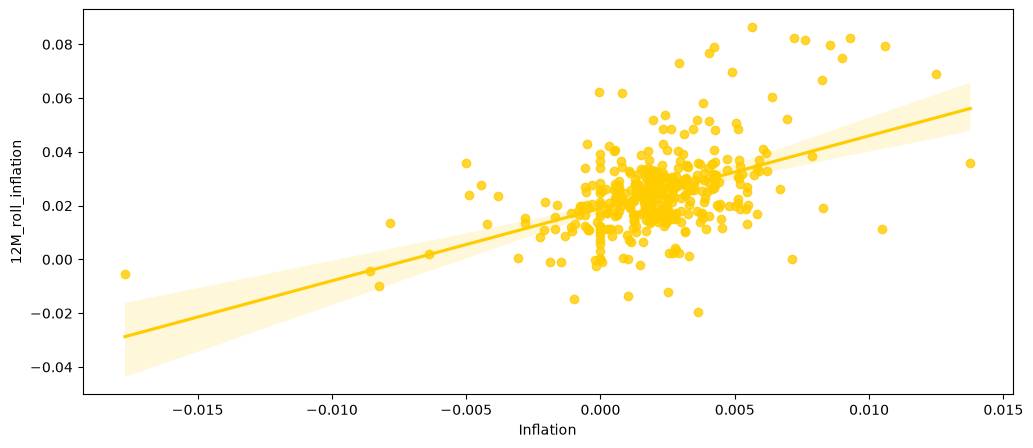

In [40]:
sns.regplot(x=df['Inflation'], y=df['12M_roll_inflation'], color=color3)
df['Inflation'].corr(df['12M_roll_inflation'])

##### Lagged rels

14
-0.07508146427690433


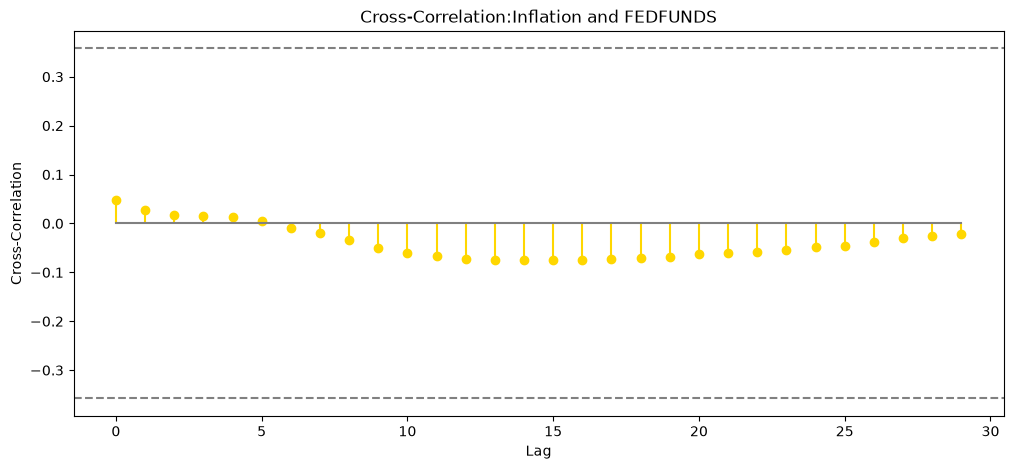

In [41]:
_ = ccf_funct(df['Inflation'].dropna(), df['FEDFUNDS'].dropna(), 30)

17
-0.1451272831289677


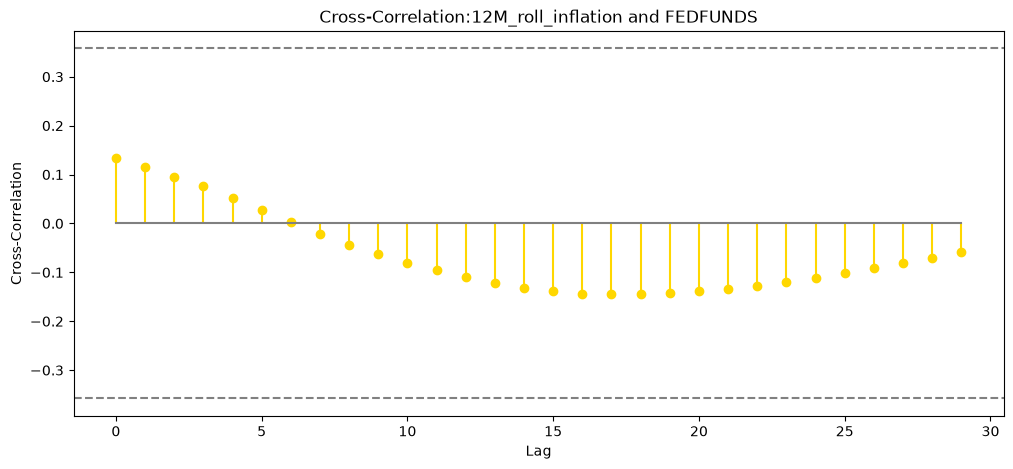

In [42]:
_ = ccf_funct(df['12M_roll_inflation'].dropna(), df['FEDFUNDS'].dropna(), 30)

2
-0.11496711674311497


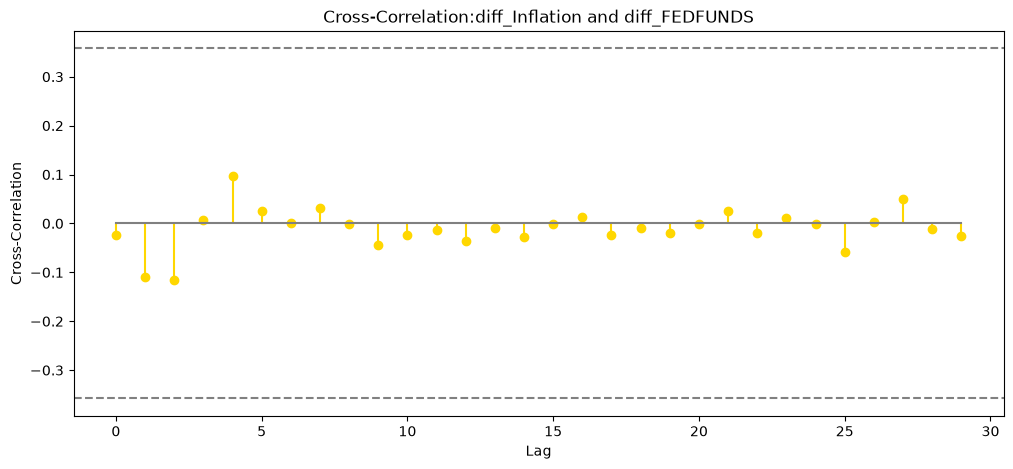

In [43]:
_ = ccf_funct(df['diff_Inflation'].dropna(), df['diff_FEDFUNDS'].dropna(), 30)

15
-0.1410331729318322


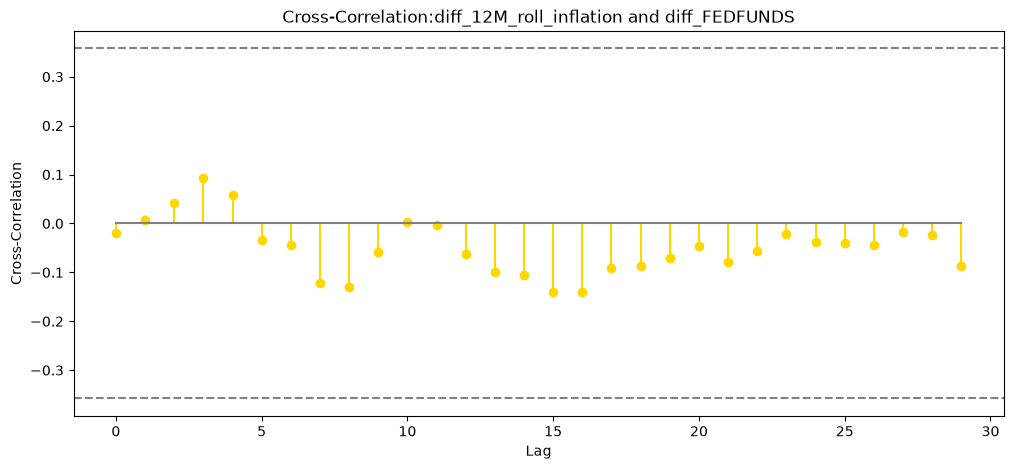

In [44]:
_ = ccf_funct(df['diff_12M_roll_inflation'].dropna(), df['diff_FEDFUNDS'].dropna(), 30)

0
0.18185923803579526


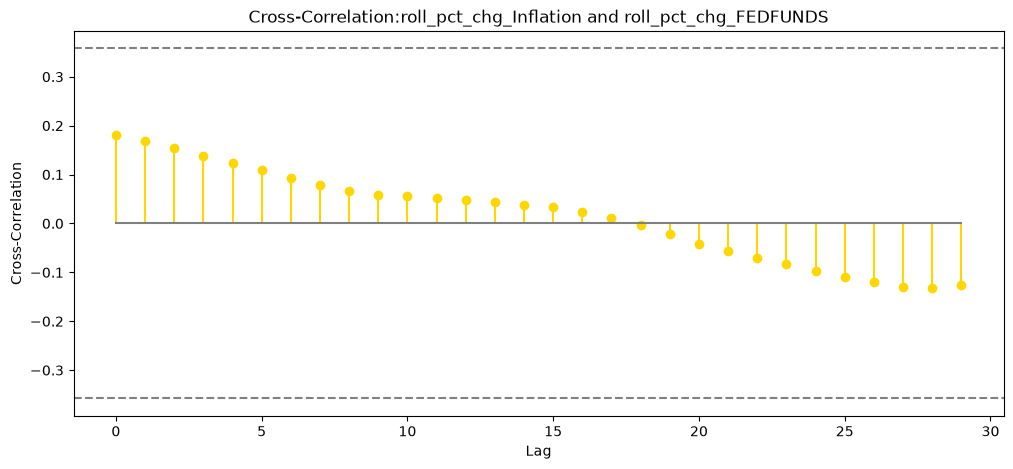

In [45]:
_ = ccf_funct(df['roll_pct_chg_Inflation'].dropna(), df['roll_pct_chg_FEDFUNDS'].dropna(), 30)

0
0.2990853267453438


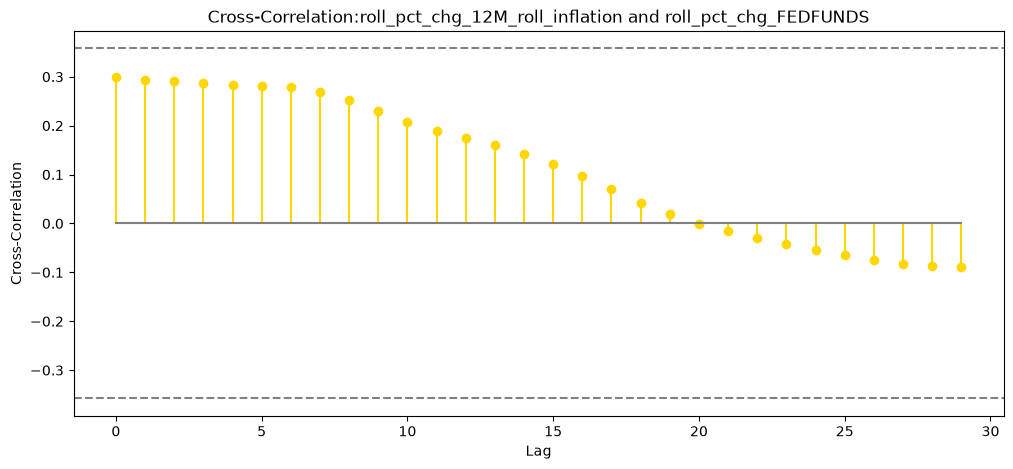

In [46]:
_ = ccf_funct(df['roll_pct_chg_12M_roll_inflation'].dropna(), df['roll_pct_chg_FEDFUNDS'].dropna(), 30)

##### Infl vs FED Funds rate

np.float64(0.13469365099563776)

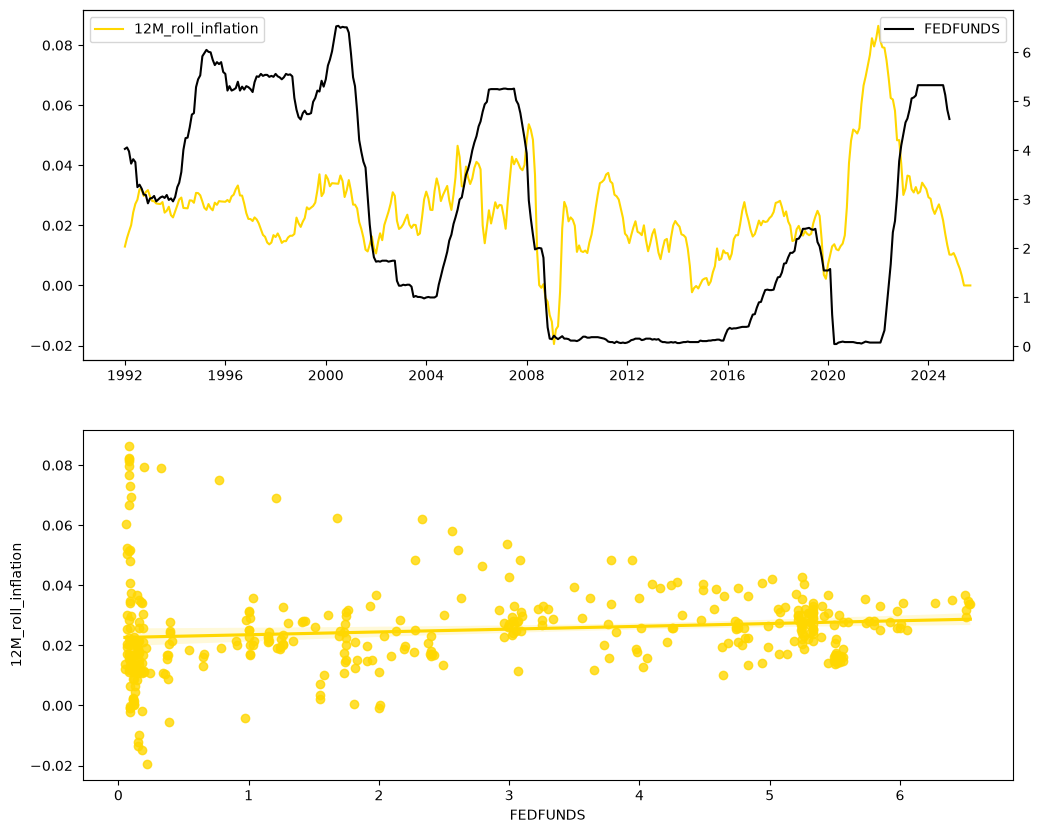

In [47]:
series_rel_plot(df['12M_roll_inflation'], df['FEDFUNDS'])

##### Inflation vs changes in M2

np.float64(-0.16755855799420652)

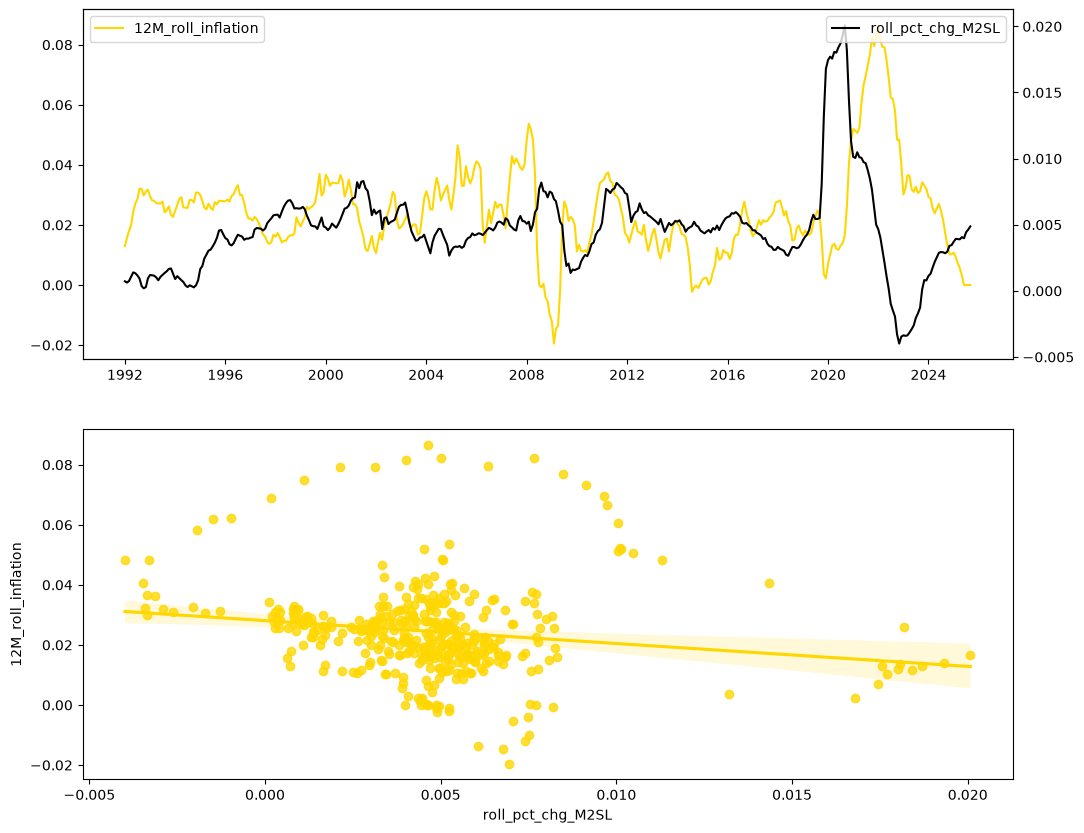

In [48]:
series_rel_plot(df['12M_roll_inflation'], df['roll_pct_chg_M2SL'])

19
0.517646046432761


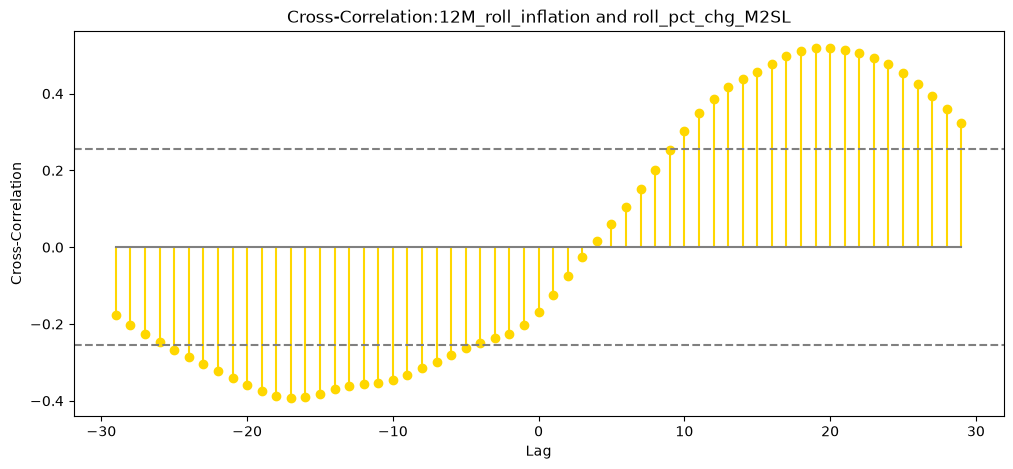

In [49]:
_ = ccf_funct(df['12M_roll_inflation'].dropna(), df['roll_pct_chg_M2SL'].dropna(), 30, both_sides=True)

np.float64(0.4919975103447992)

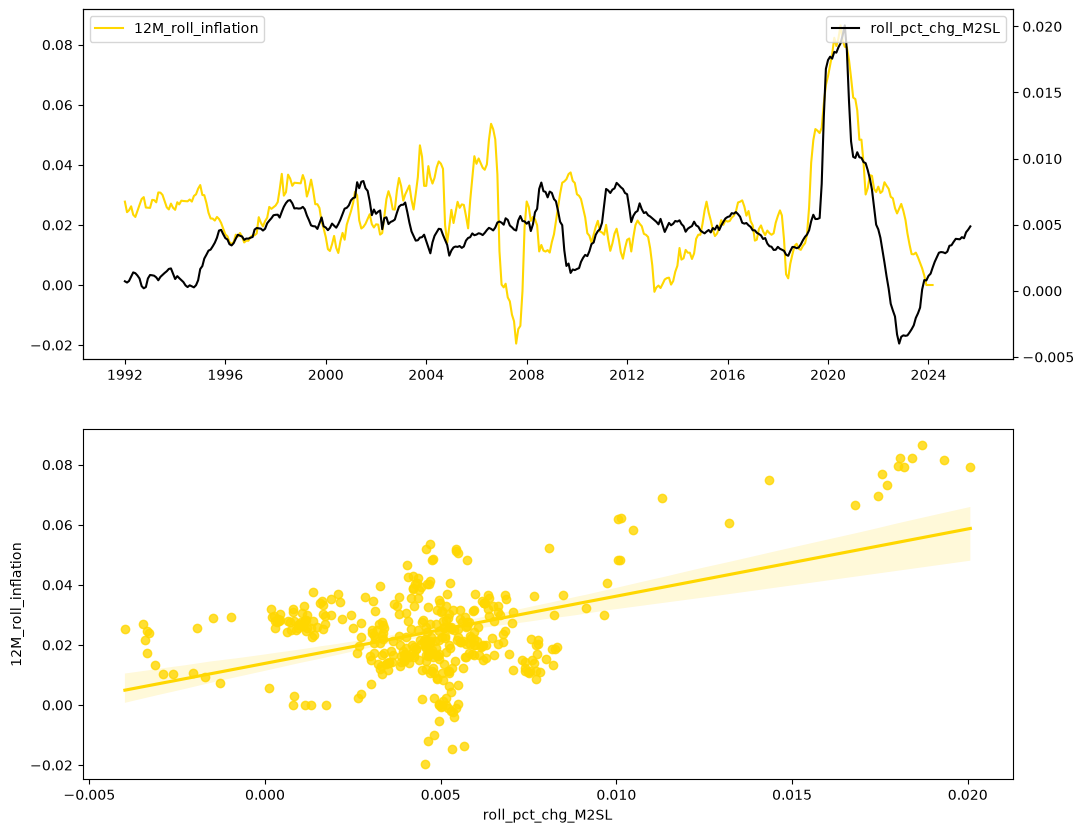

In [50]:
series_rel_plot(df['12M_roll_inflation'].shift(-18), df['roll_pct_chg_M2SL'])

### Mortgage vs real estate

19
-0.7467249864743931


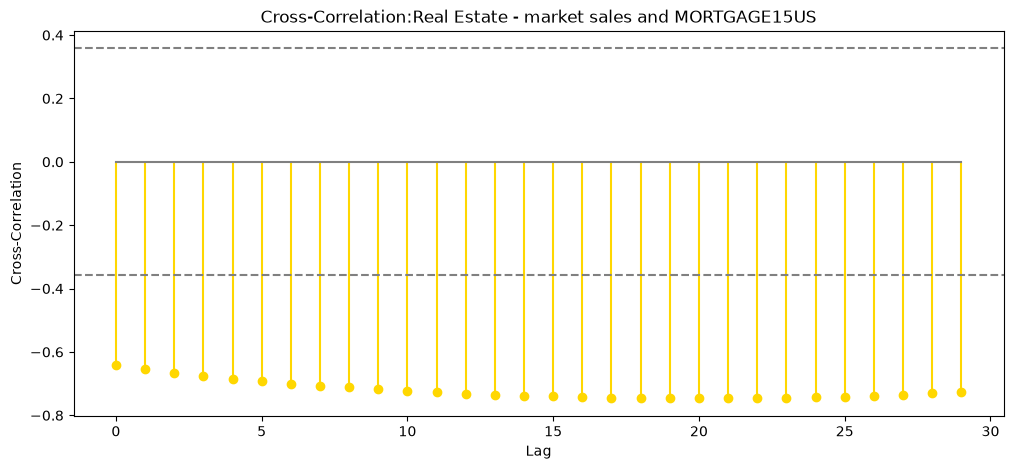

In [51]:
_ = ccf_funct(df['Real Estate - market sales'].dropna(), df['MORTGAGE15US'].dropna(), 30)

3
-0.2372780033112821


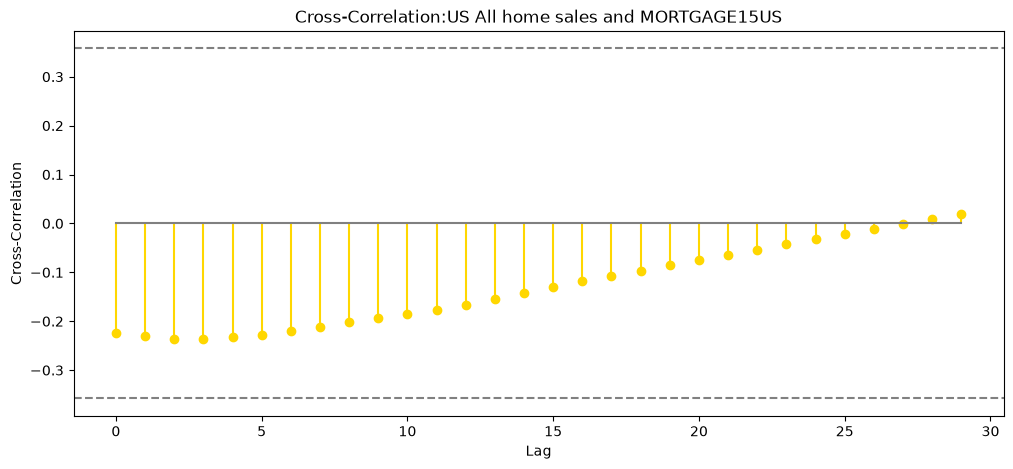

In [52]:
_ = ccf_funct(df['US All home sales'].dropna(), df['MORTGAGE15US'].dropna(), 30)

PearsonRResult(statistic=np.float64(-0.22358463720698382), pvalue=np.float64(7.4371622214193065e-06))

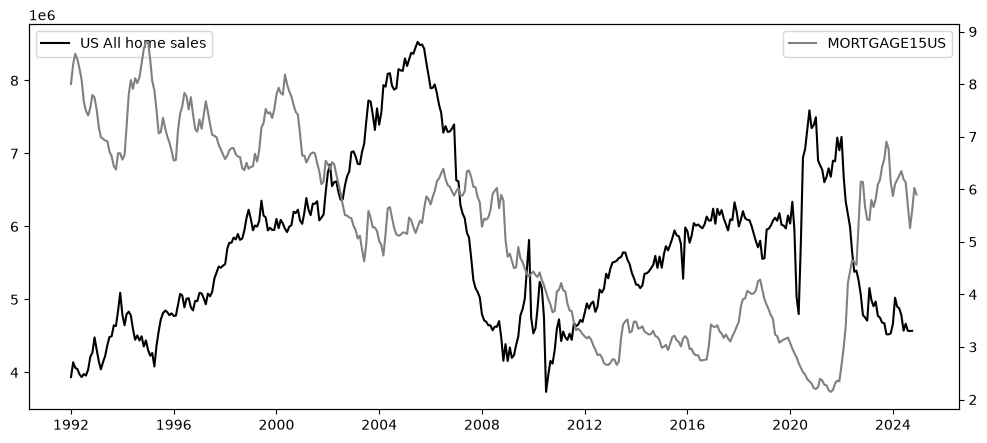

In [53]:
dual_plot_corr(df['US All home sales'], df['MORTGAGE15US'])

3
-0.5889580324466692


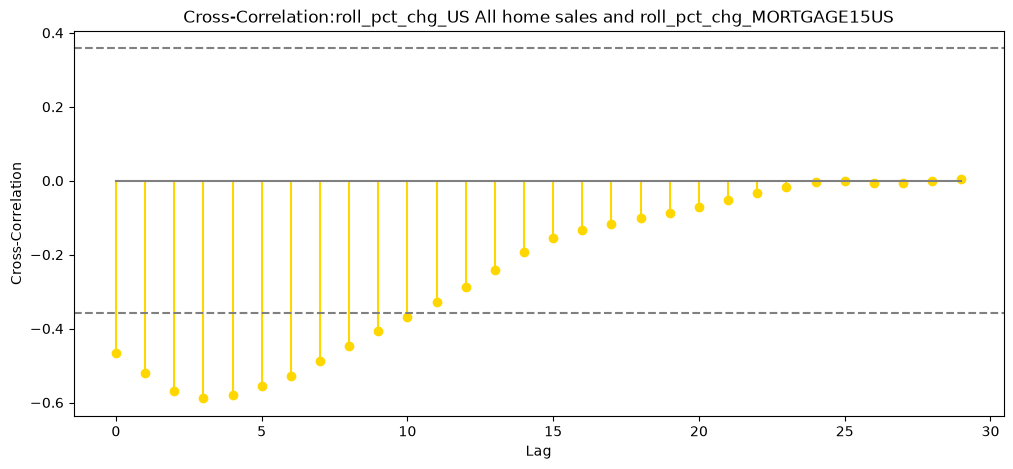

In [54]:
_ = ccf_funct(df['roll_pct_chg_US All home sales'].dropna(), df['roll_pct_chg_MORTGAGE15US'].dropna(), 30)

PearsonRResult(statistic=np.float64(-0.4678300039646929), pvalue=np.float64(3.804942540545431e-23))

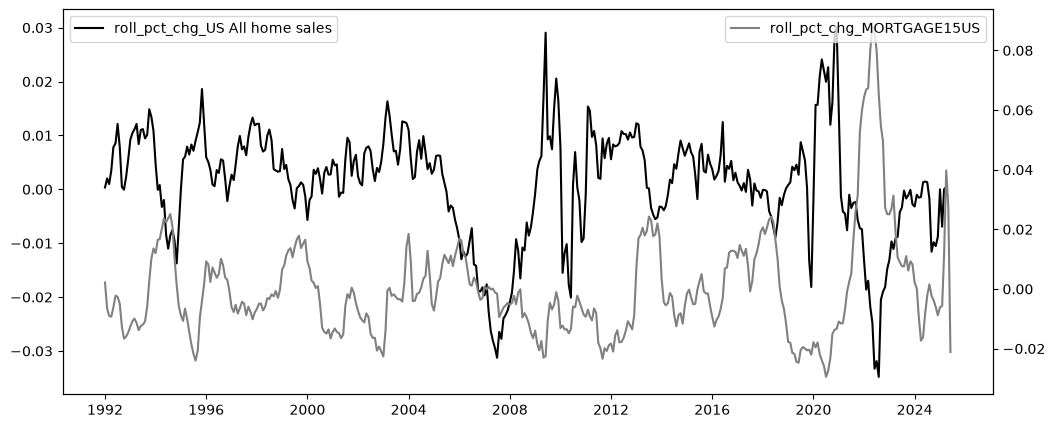

In [55]:
dual_plot_corr(df['roll_pct_chg_US All home sales'], df['roll_pct_chg_MORTGAGE15US'])

### Asset relationships and money supply

#### Intro

np.float64(0.935091635491198)

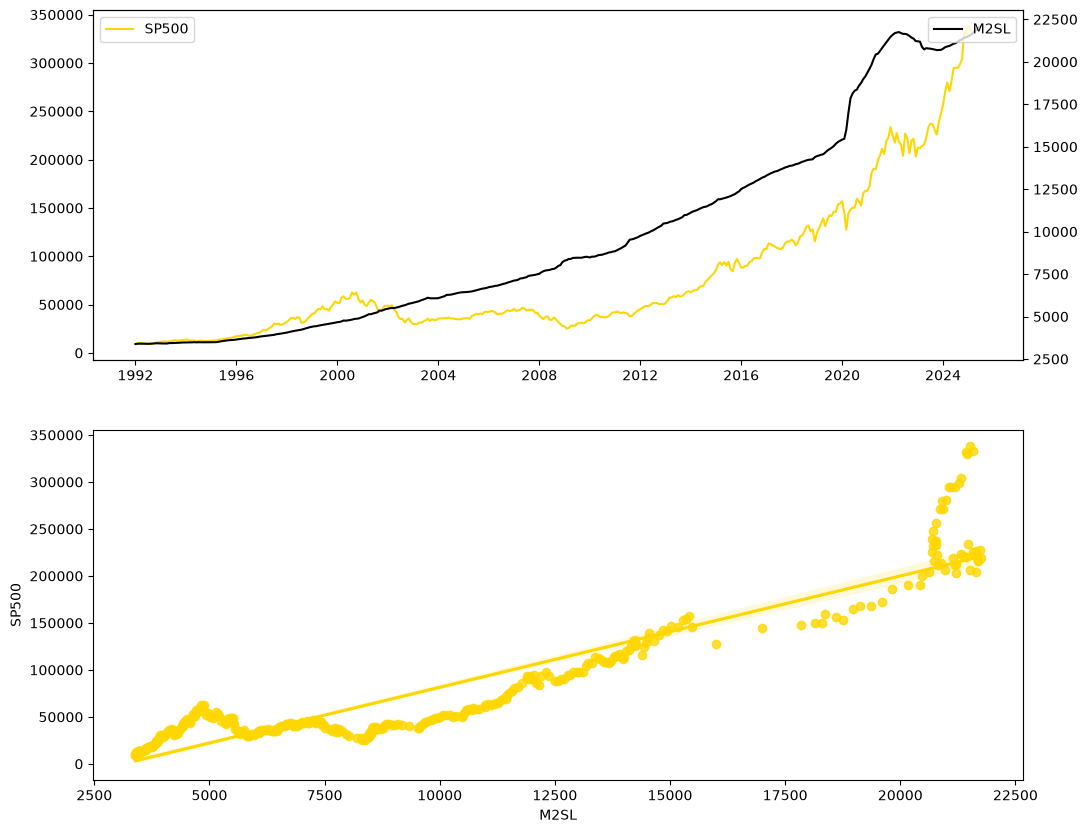

In [56]:
series_rel_plot(df['SP500'], df['M2SL'])

(1000.0, 35000.0)

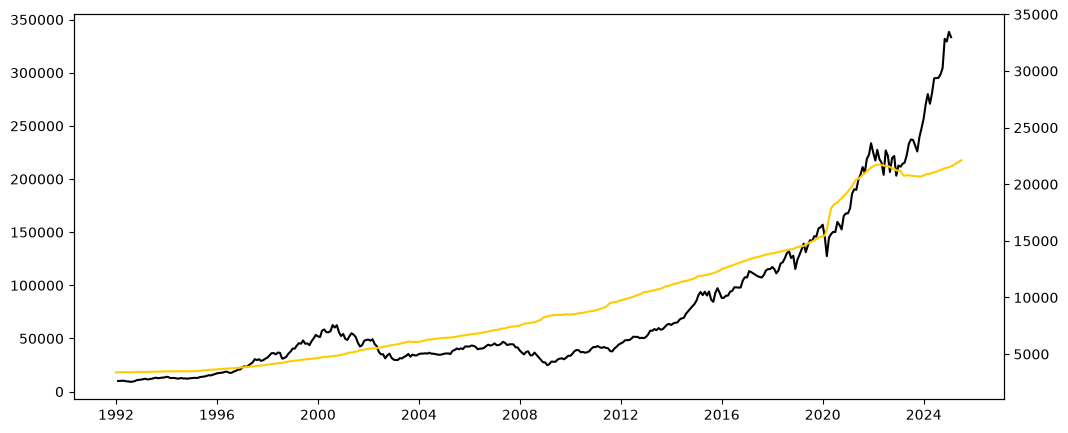

In [57]:
plt.plot(df['SP500'], color=color1)
ax2 = plt.twinx()
ax2.plot(df['M2SL'], color=color3)
ax2.set_ylim([1000, 35000])

np.float64(-0.008457227374231923)

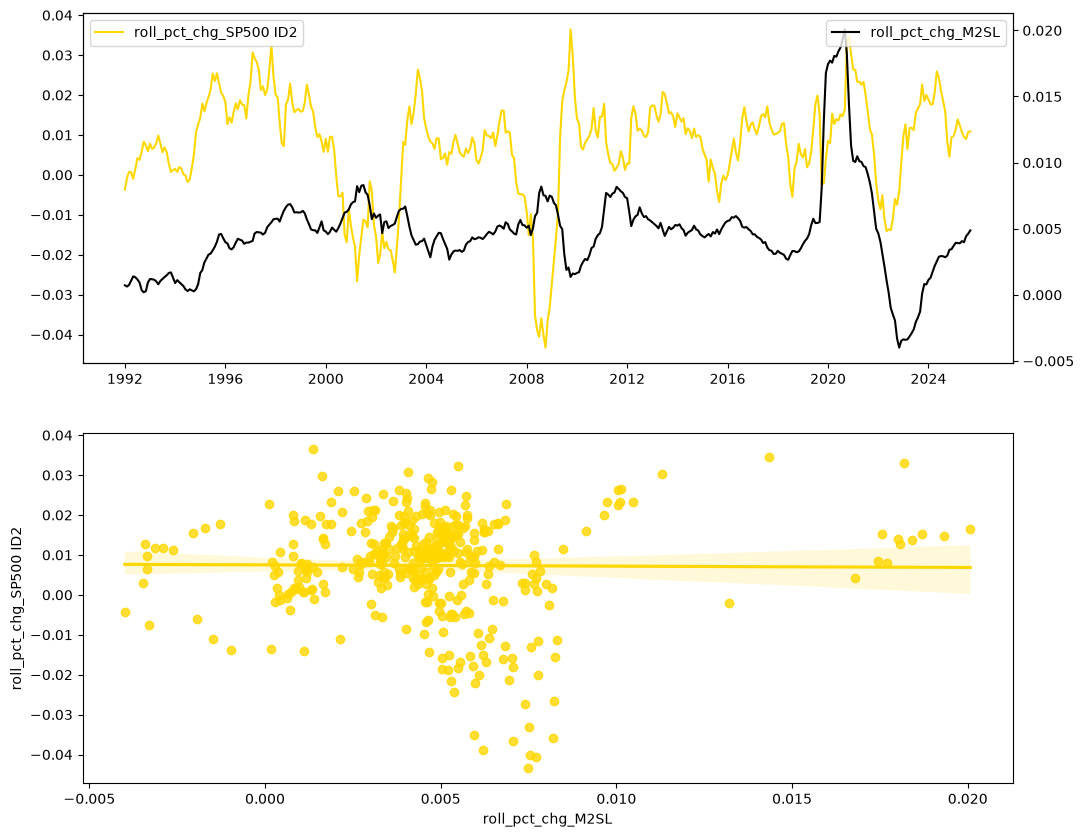

In [58]:
series_rel_plot(df['roll_pct_chg_SP500 ID2'], df['roll_pct_chg_M2SL'].shift(0))

np.float64(0.030994655042830603)

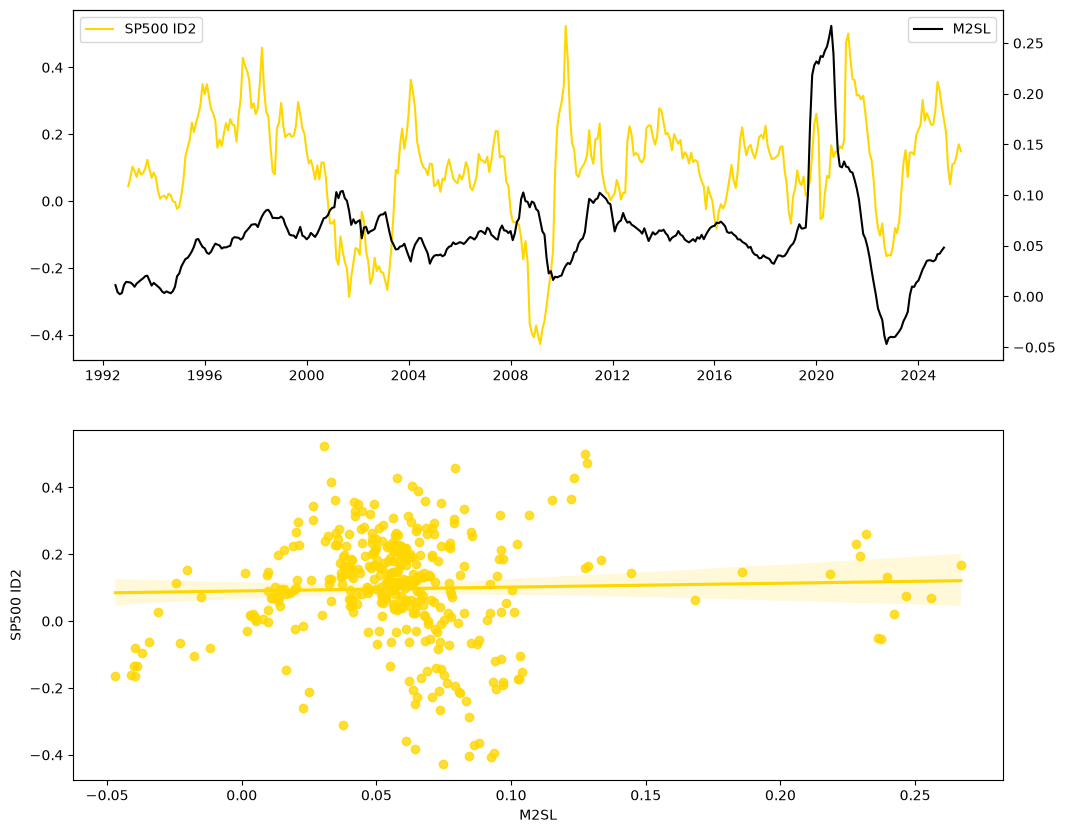

In [59]:
s1 = df['SP500 ID2'].pct_change(periods=12, fill_method=None)
s2 = df['M2SL'].pct_change(periods=12, fill_method=None).shift(-6)

series_rel_plot(s1,s2)

np.float64(-0.2603629070502847)

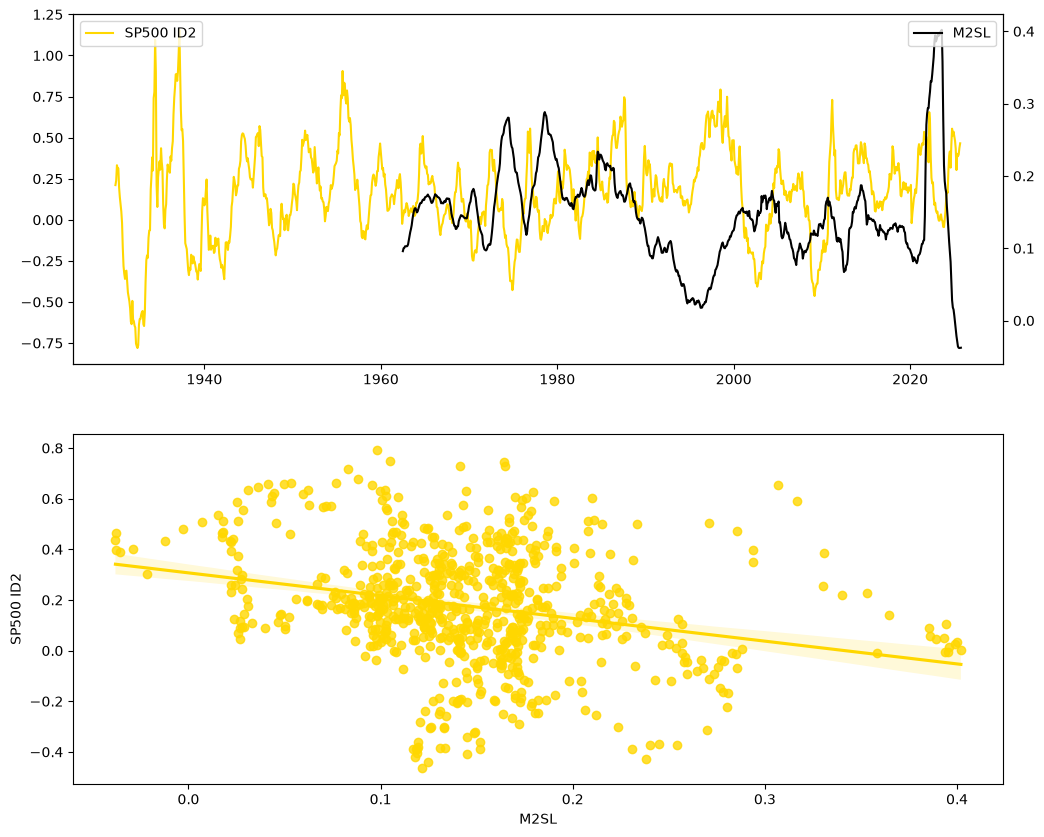

In [60]:
s1 = result_df['SP500 ID2'].pct_change(periods=24, fill_method=None)
s2 = result_df['M2SL'].pct_change(periods=24, fill_method=None).shift(18)

series_rel_plot(s1,s2)

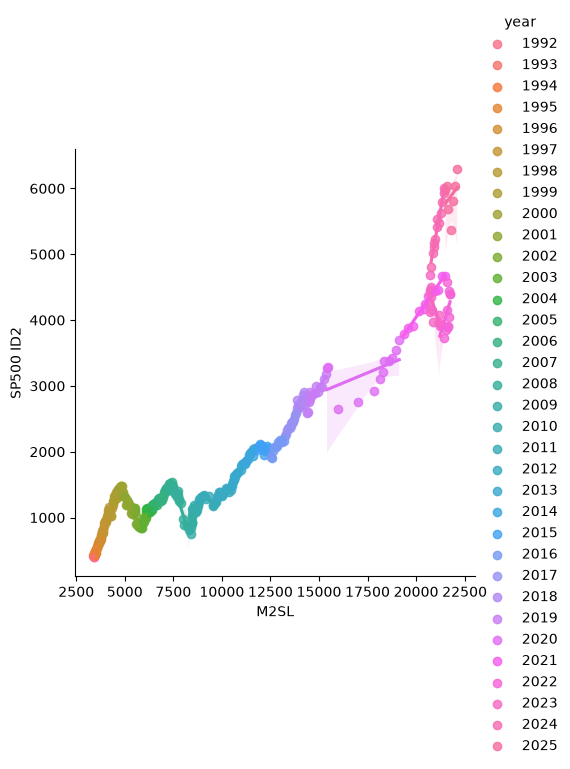

In [61]:
df['year'] = df.index.year
sns.lmplot(data=df, x='M2SL', y='SP500 ID2', hue='year')

<Axes: xlabel='Consumer Price Index', ylabel='SP500 ID2'>

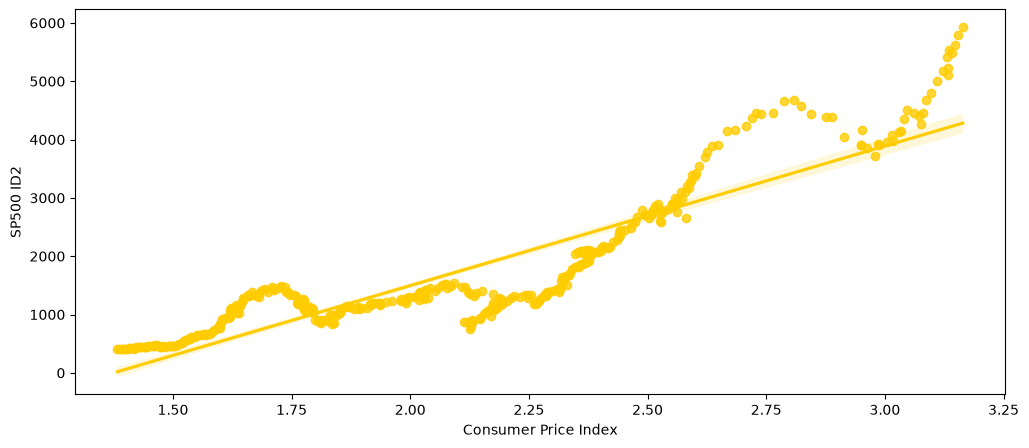

In [62]:
sns.regplot(x=df['Consumer Price Index'], y=df['SP500 ID2'], color=color3)

<Axes: xlabel='Average Sales Price of Houses Sold', ylabel='SP500 ID2'>

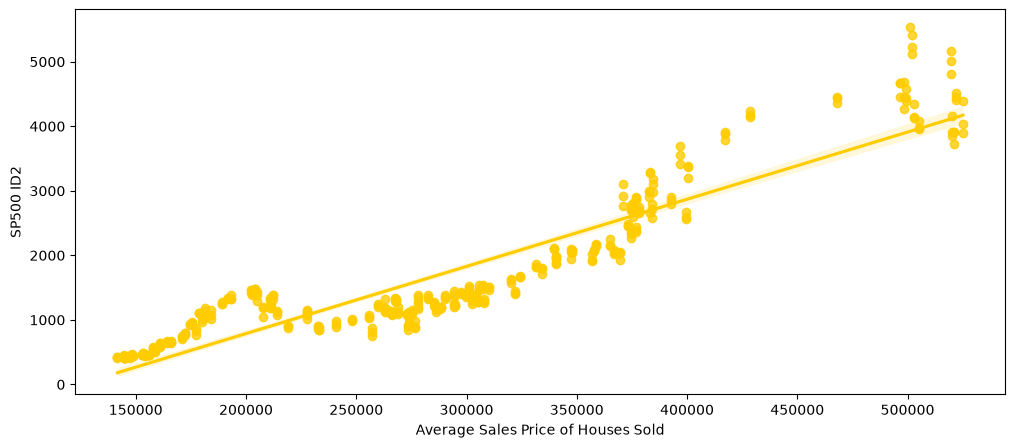

In [63]:
sns.regplot(x=df['Average Sales Price of Houses Sold'], y=df['SP500 ID2'], color=color3)

<Axes: xlabel='gold', ylabel='SP500 ID2'>

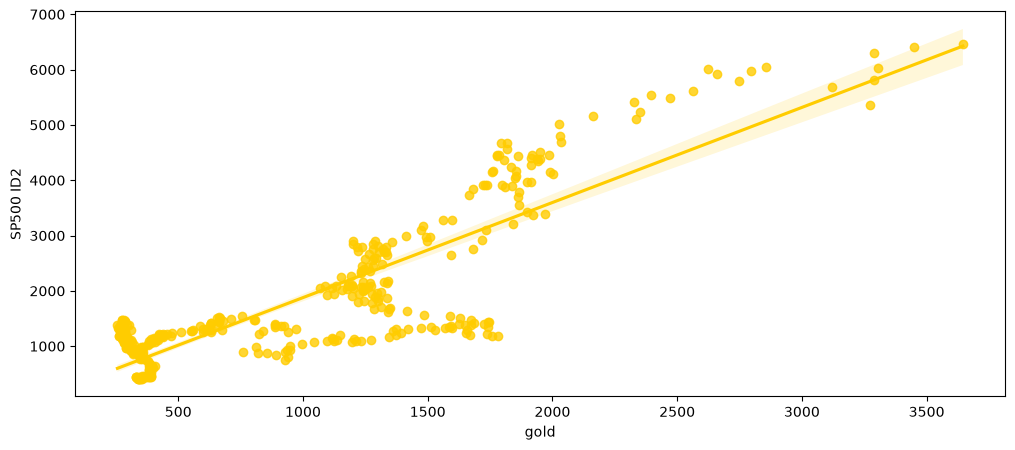

In [64]:
sns.regplot(x=df['gold'], y=df['SP500 ID2'], color=color3)

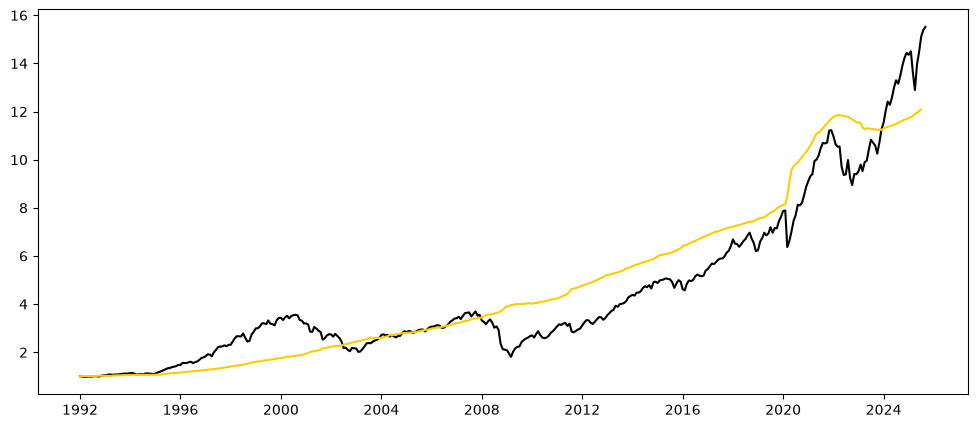

In [65]:
plt.plot(df['SP500 ID2']/df['SP500 ID2'].dropna().iloc[0], color=color1)
plt.plot(2 * df['M2SL']/df['M2SL'].iloc[0] - 1, color=color3)

#### Money supply

In [66]:
df['FED balance sheet'] = df['FED balance sheet']/1e3

<Axes: >

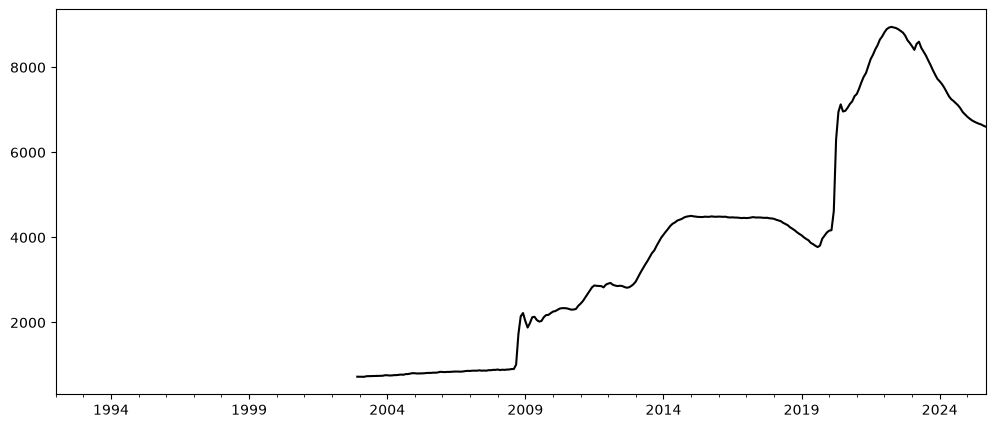

In [67]:
df['FED balance sheet'].plot(color=color1)

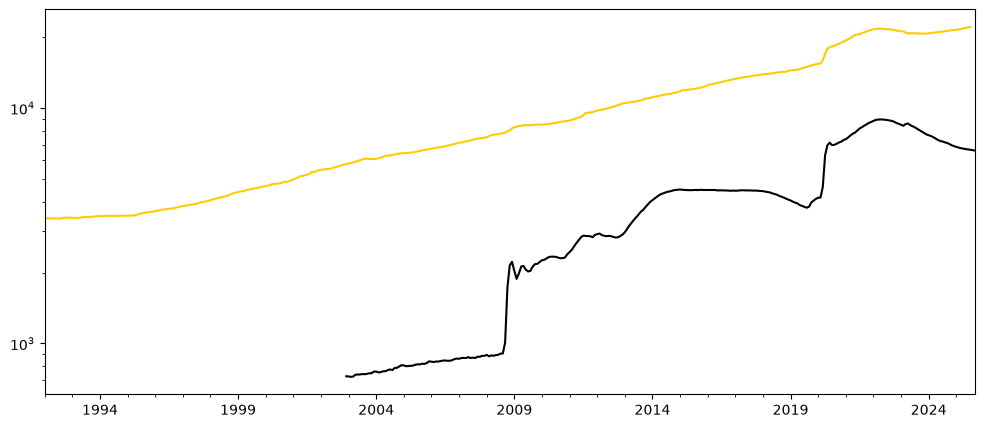

In [68]:
df['M2SL'].plot(color=color3)
df['FED balance sheet'].plot(color=color1)
plt.yscale('log')

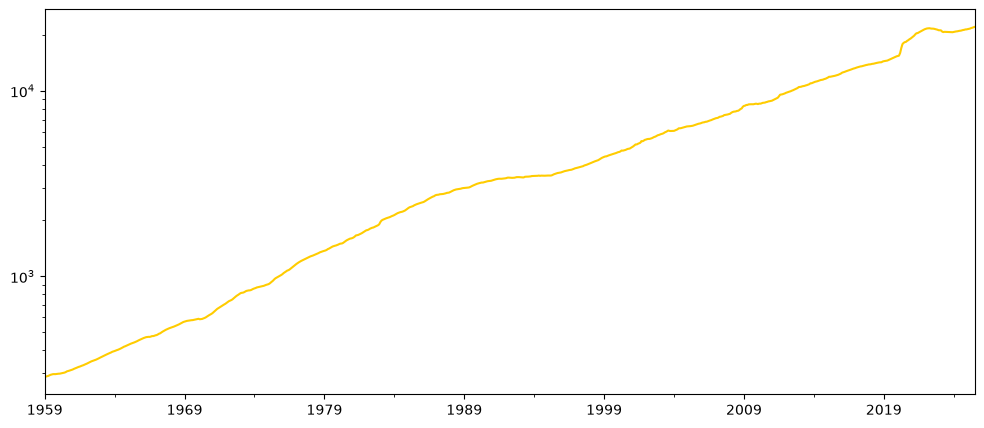

In [69]:
result_df['M2SL'].dropna().plot(color=color3)
# df['FED balance sheet'].plot(color=color1)
plt.yscale('log')

0.06539172549776837


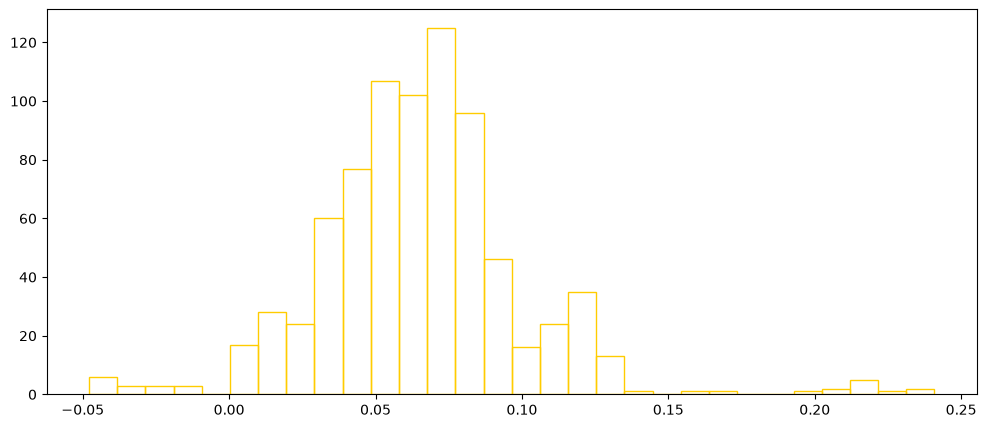

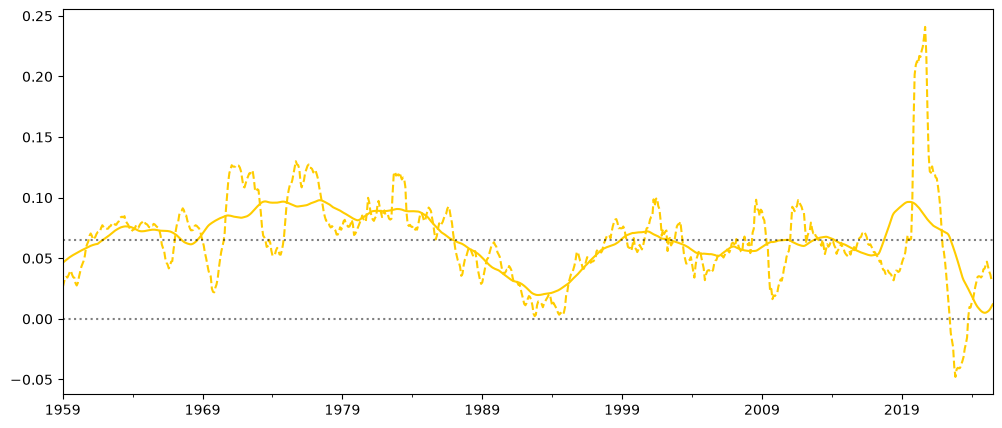

In [70]:
M2_incr_s = result_df['M2SL'].dropna().pct_change().rolling(window=12, min_periods=1, center=True).sum()
plt.hist(M2_incr_s, bins=30, fill=None, edgecolor=color3)
print(M2_incr_s.mean())
plt.figure()
M2_incr_s.plot(color=color3, linestyle='--')
M2_incr_s.rolling(window=60, min_periods=1, center=True).mean().plot(color=color3)
plt.axhline(0, color=color1, alpha=0.5, linestyle=':')
plt.axhline(M2_incr_s.mean(), color=color1, alpha=0.5, linestyle=':')

<Axes: >

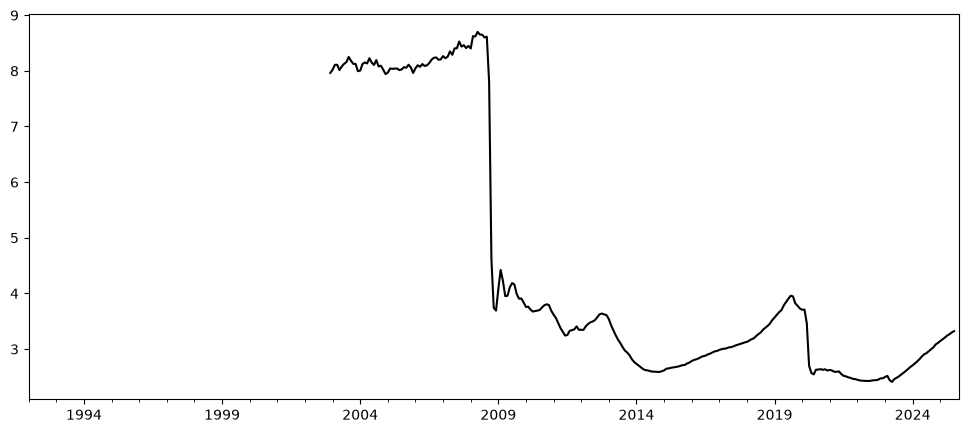

In [71]:
(df['M2SL'] / df['FED balance sheet']).plot(color=color1)

<Axes: >

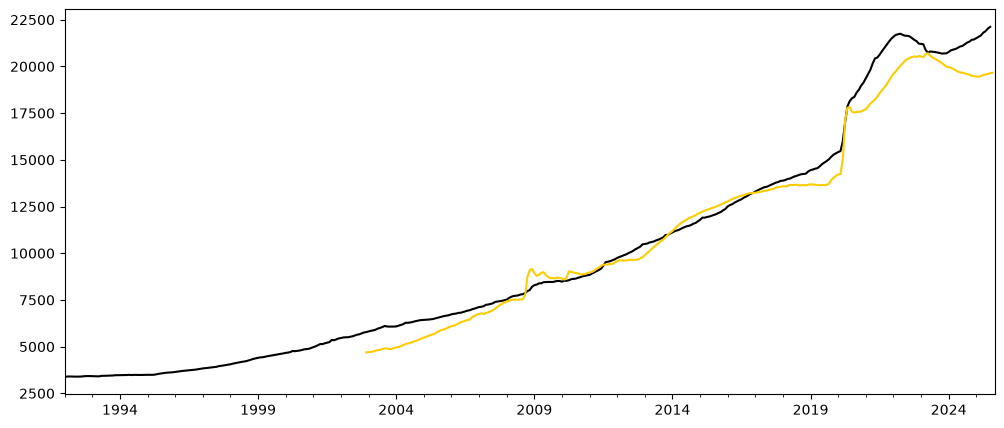

In [72]:
df['M2SL'].plot(color=color1)
(df['LOANS'] + df['FED balance sheet']).plot(color=color3)

(0.0, 1.2)

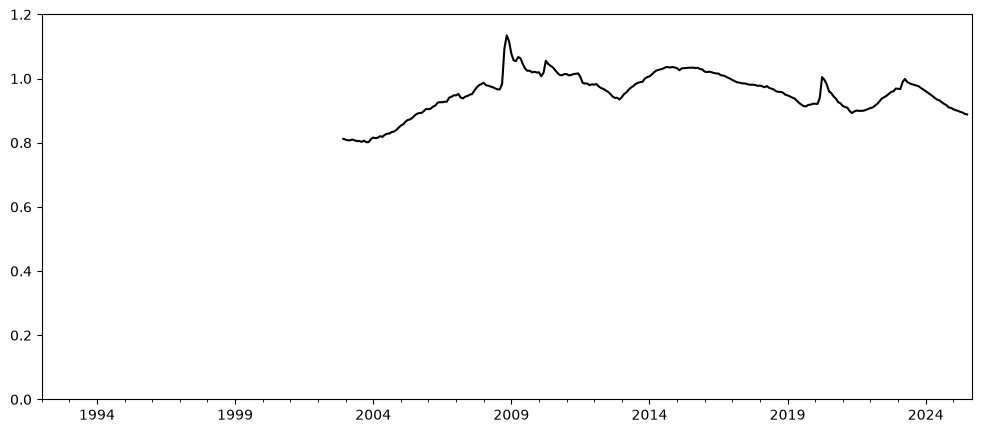

In [73]:
((df['LOANS'] + df['FED balance sheet']) / df['M2SL']).plot(color=color1)
plt.ylim([0,1.2])

<Axes: >

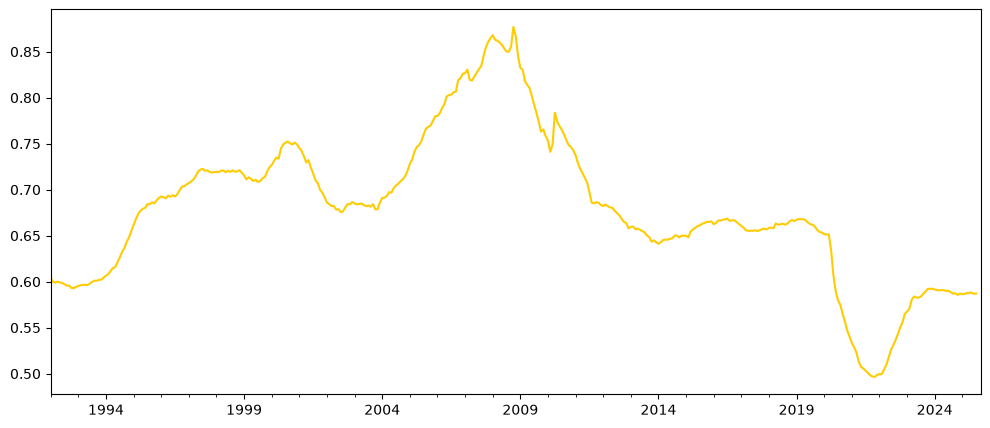

In [74]:
(df['LOANS'] / df['M2SL']).plot(color=color3)

<Axes: >

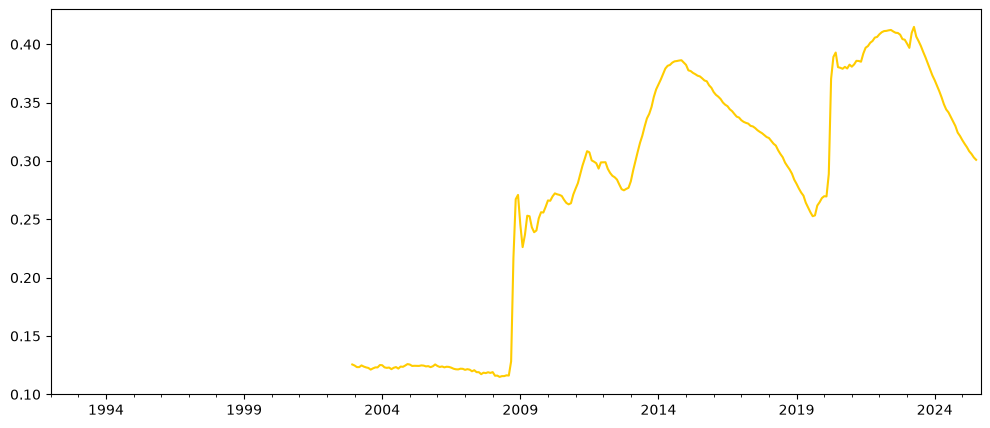

In [75]:
(df['FED balance sheet'] / df['M2SL']).plot(color=color3)

<Axes: >

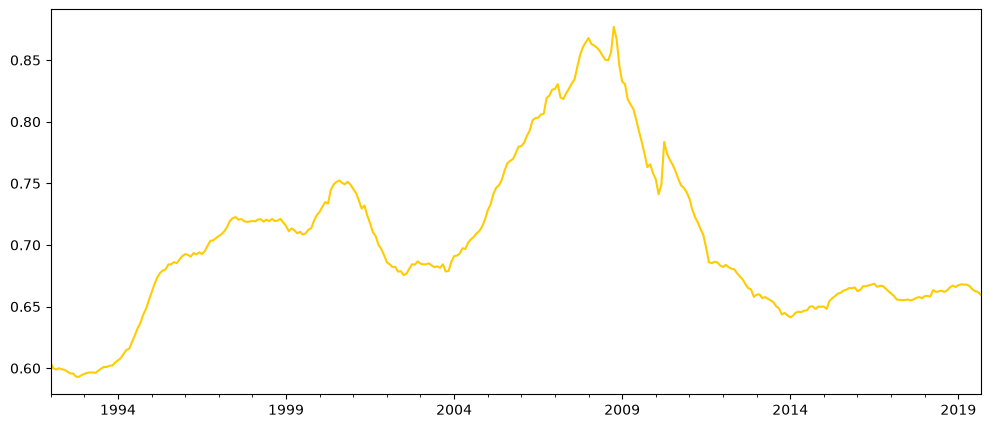

In [84]:
short_df = df[df.index < "2019-10-01"]
(short_df['LOANS'] / short_df['M2SL']).plot(color=color3)

<Axes: xlabel='LOANS', ylabel='M2SL'>

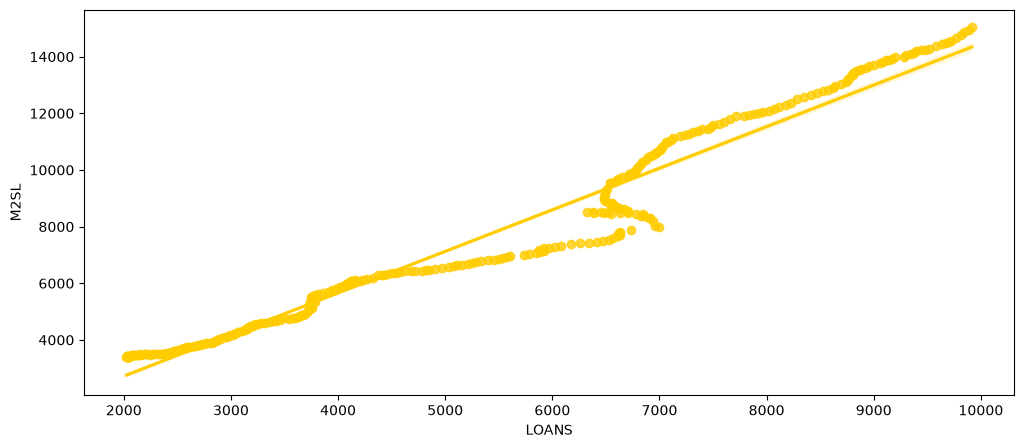

In [85]:
sns.regplot(x=short_df['LOANS'], y=short_df['M2SL'], color=color3)

-29
0.6364850795037358


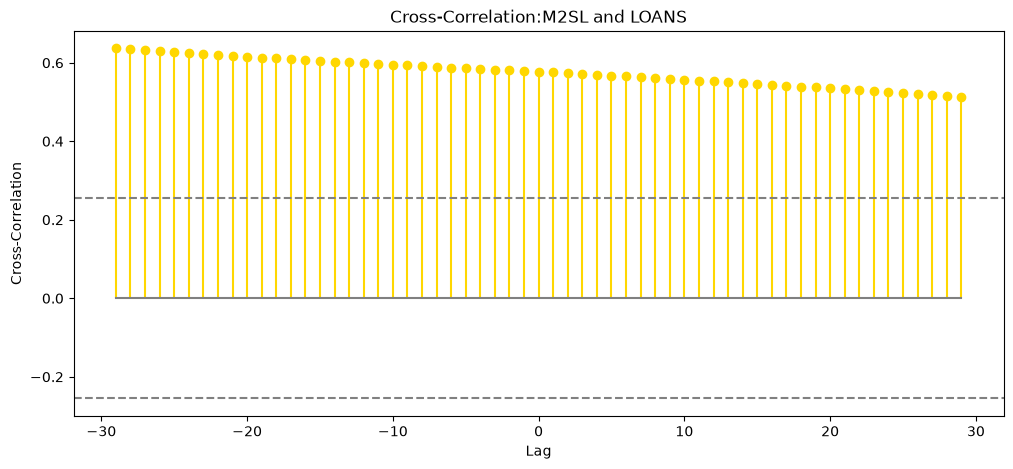

In [86]:
IR_MORT_ccf = ccf_funct(result_df['M2SL'].dropna(), result_df['LOANS'].dropna(), 30, both_sides=True)

np.float64(0.06369033768982071)

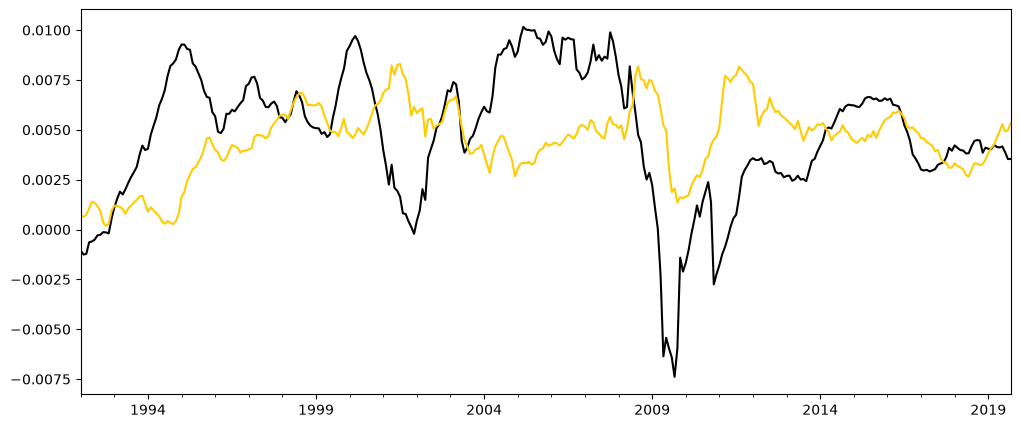

In [87]:
s1 = short_df['LOANS'].pct_change(fill_method=None).rolling(window=12, min_periods=1, center=True).mean()
s2 = short_df['M2SL'].pct_change(fill_method=None).rolling(window=12, min_periods=1, center=True).mean()

s1.plot(color=color1)
s2.plot(color=color3)

s1.corr(s2)

28
-0.28300969932179576


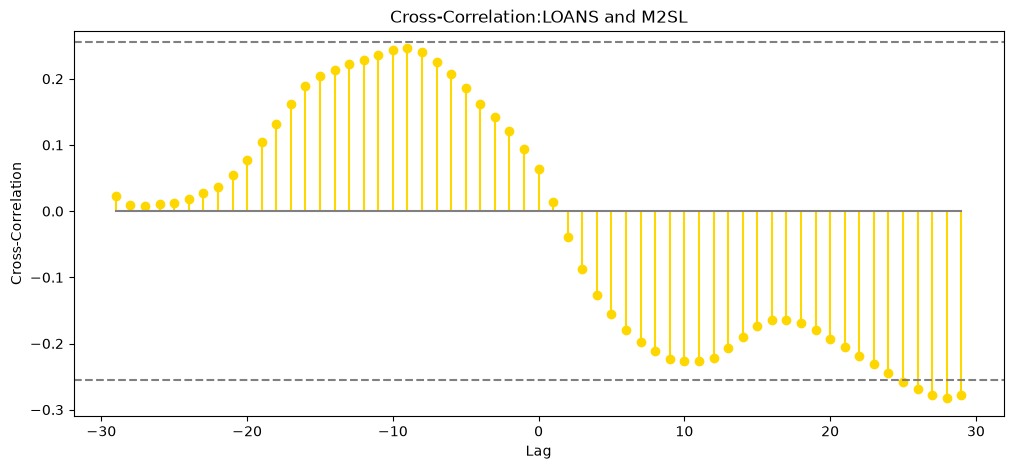

In [88]:
IR_MORT_ccf = ccf_funct(s1.dropna(), s2.dropna(), 30, both_sides=True)

<Axes: xlabel='LOANS', ylabel='M2SL'>

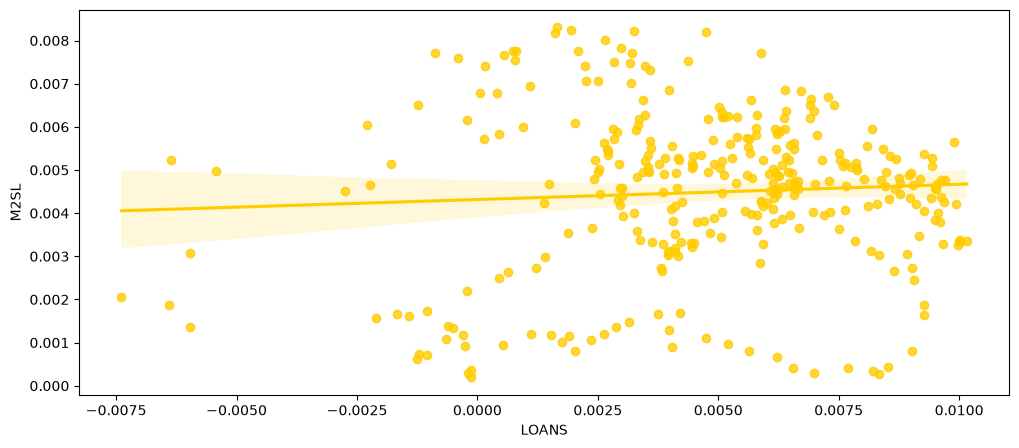

In [89]:
sns.regplot(x=s1, y=s2, color=color3)

np.float64(0.5840245687751333)

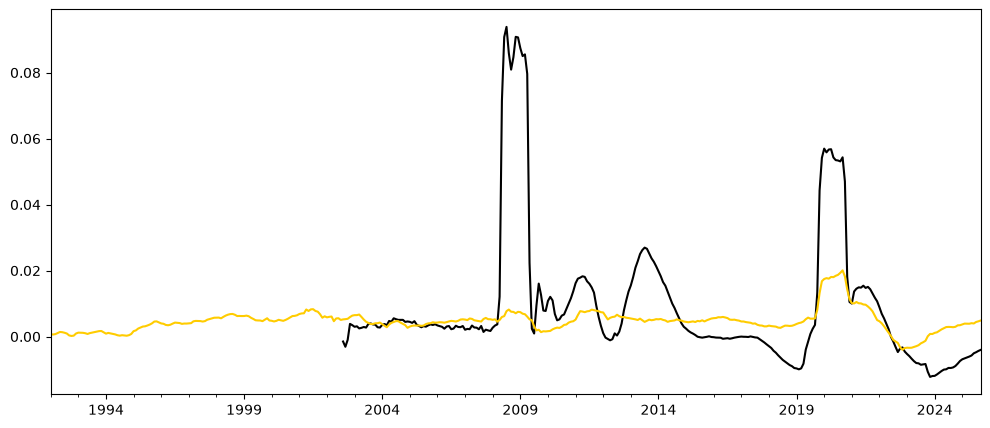

In [90]:
s1 = df['FED balance sheet'].pct_change(fill_method=None).rolling(window=12, min_periods=1, center=True).mean()
s2 = df['M2SL'].pct_change(fill_method=None).rolling(window=12, min_periods=1, center=True).mean()

s1.plot(color=color1)
s2.plot(color=color3)

s1.corr(s2)

(-0.04, 0.12)

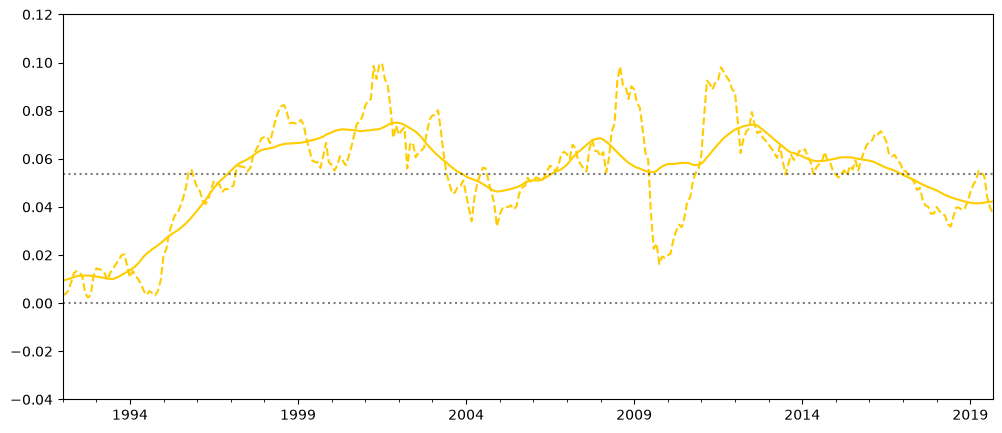

In [91]:
s3 = short_df['M2SL'].pct_change(fill_method=None).rolling(window=12, min_periods=1, center=True).sum()

s3.plot(color=color3, linestyle='--')
s3.rolling(window=36, min_periods=1, center=True).mean().plot(color=color3)
plt.axhline(0, color=color1, alpha=0.5, linestyle=':')
plt.axhline(s3.mean(), color=color1, alpha=0.5, linestyle=':')
plt.ylim([-0.04,0.12])

23
0.10770482875087053


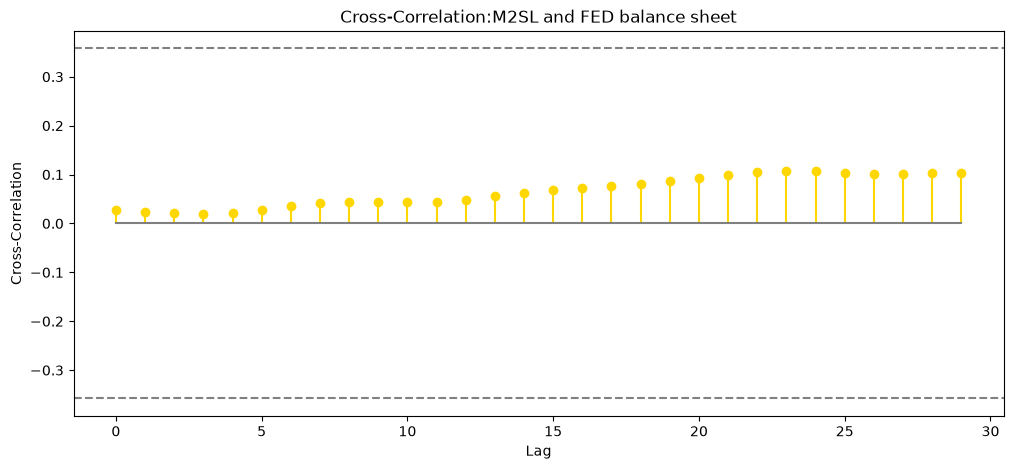

In [92]:
IR_MORT_ccf = ccf_funct(s2.dropna(), s1.dropna(), 30, both_sides=False)

<Axes: xlabel='FED balance sheet', ylabel='M2SL'>

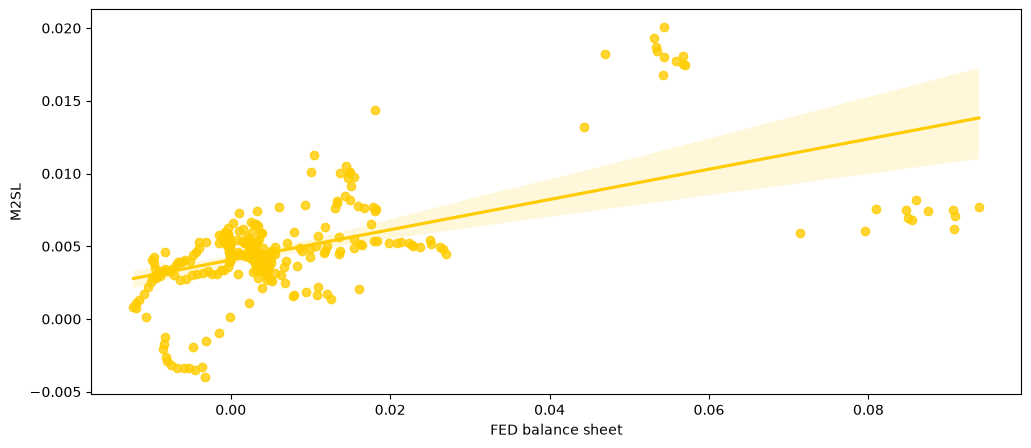

In [93]:
sns.regplot(x=s1, y=s2, color=color3)

#### M2 Changes

(-0.04, 0.12)

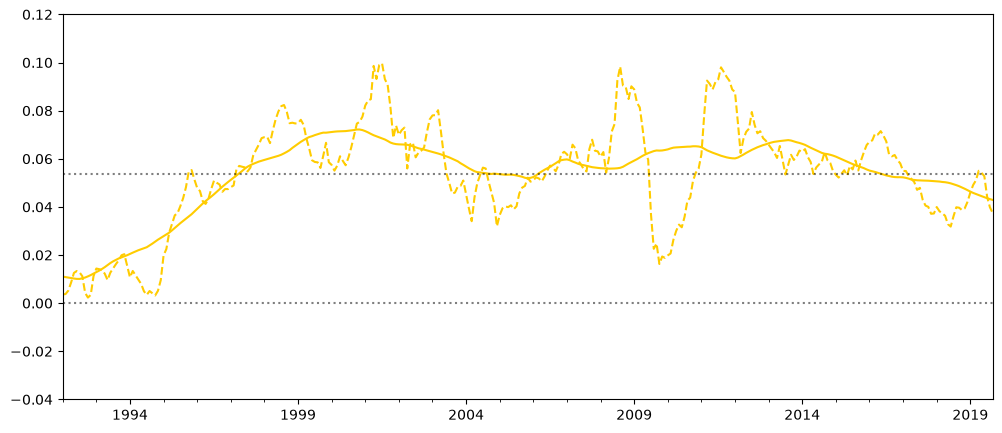

In [94]:
s3 = short_df['M2SL'].pct_change(fill_method=None).rolling(window=12, min_periods=1, center=True).sum()

s3.plot(color=color3, linestyle='--')
s3.rolling(window=60, min_periods=1, center=True).mean().plot(color=color3)
plt.axhline(0, color=color1, alpha=0.5, linestyle=':')
plt.axhline(s3.mean(), color=color1, alpha=0.5, linestyle=':')
plt.ylim([-0.04,0.12])

#### All

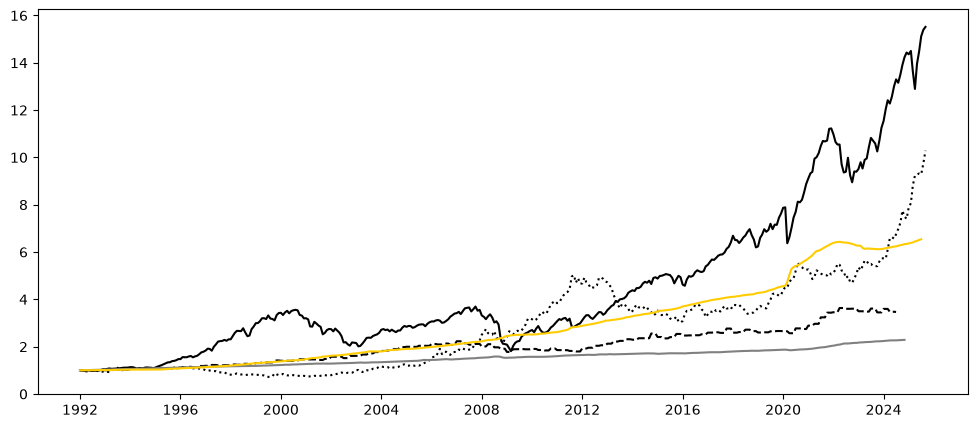

In [95]:
plt.plot(df['SP500 ID2']/df['SP500 ID2'].dropna().iloc[0], color=color1)
plt.plot(df['Average Sales Price of Houses Sold']/df['Average Sales Price of Houses Sold'].iloc[0], color=color1, linestyle='--')
plt.plot(df['gold']/df['gold'].iloc[0], color=color1, linestyle=':')

plt.plot(df['Consumer Price Index']/df['Consumer Price Index'].iloc[0], color=color2)
plt.plot(df['M2SL']/df['M2SL'].iloc[0], color=color3)

# plt.yscale('log')

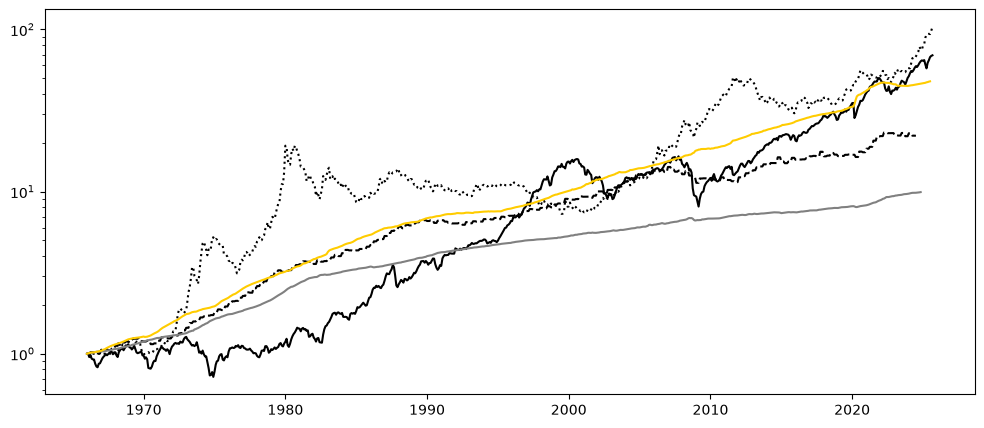

In [96]:
result_df['year'] = result_df.index.year
short_df = result_df[result_df['year']>1965]

plt.plot(short_df['SP500 ID2']/short_df['SP500 ID2'].dropna().iloc[0], color=color1)
plt.plot(short_df['Average Sales Price of Houses Sold']/short_df['Average Sales Price of Houses Sold'].dropna().iloc[0], color=color1, linestyle='--')
plt.plot(short_df['gold']/short_df['gold'].dropna().iloc[0], color=color1, linestyle=':')

plt.plot(short_df['Consumer Price Index']/short_df['Consumer Price Index'].dropna().iloc[0], color=color2)
plt.plot(short_df['M2SL']/short_df['M2SL'].dropna().iloc[0], color=color3)

plt.yscale('log')

In [97]:
[x for x in original_cols if 'M2' in x]

['M2SL']

#### SP500

In [98]:
divisor = 55e12/6500
divisor/1e9

8.461538461538462

(0.0, 10.0)

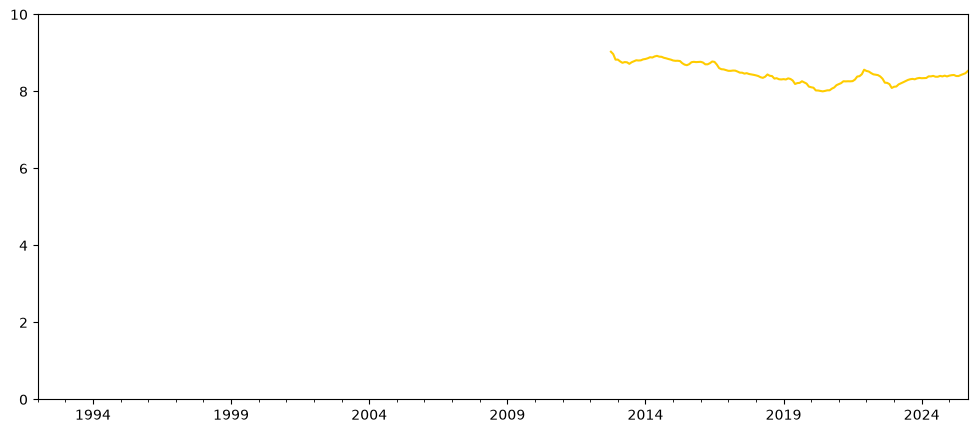

In [99]:
(1000 * df['SP500 MC']/df['SP500 ID2']).rolling(window=12, min_periods=1, center=True).mean().plot(color=color3)
plt.ylim([0,10])

<Axes: >

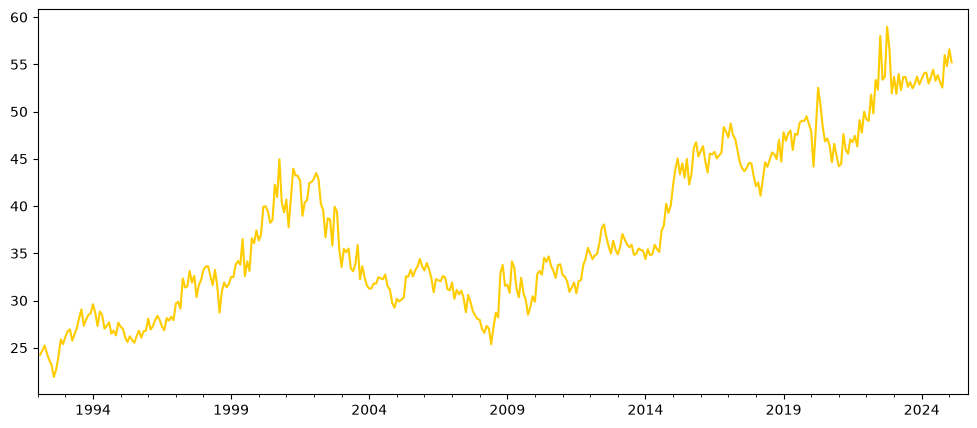

In [100]:
(df['SP500']/df['SP500 ID2']).plot(color=color3)

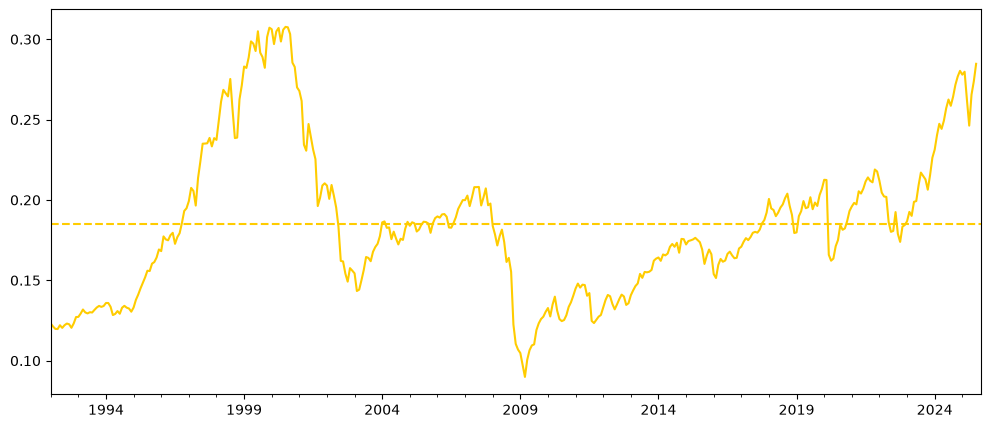

In [101]:
(df['SP500 ID2']/df['M2SL']).plot(color=color3)
plt.axhline((df['SP500 ID2']/df['M2SL']).mean(), color=color3, ls='--')

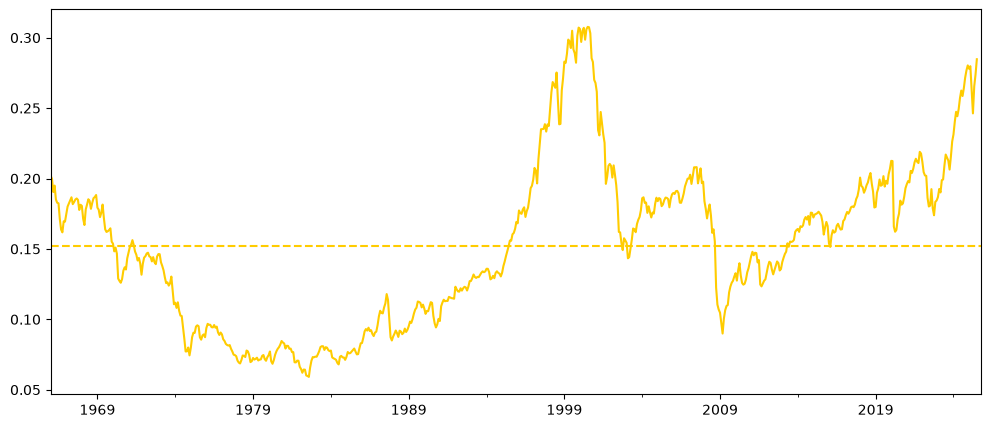

In [102]:
(short_df['SP500 ID2']/short_df['M2SL']).plot(color=color3)
plt.axhline((short_df['SP500 ID2']/short_df['M2SL']).mean(), color=color3, ls='--')

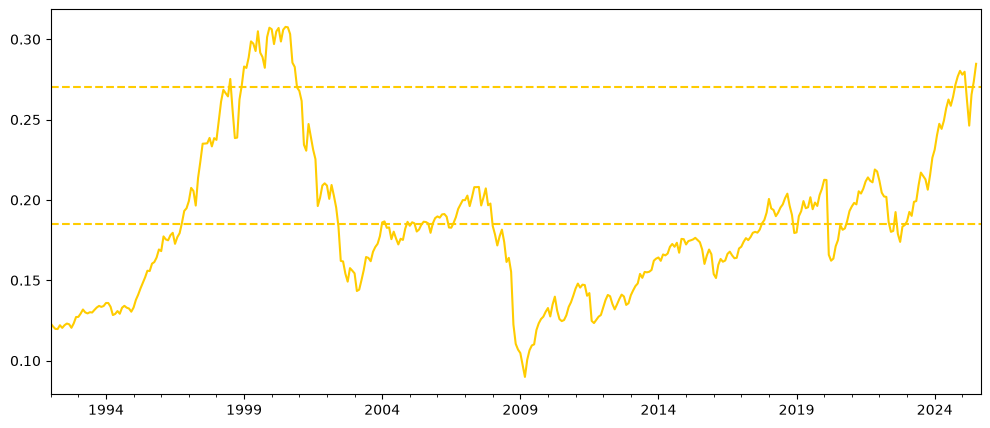

In [103]:
(df['SP500 ID2']/df['M2SL']).plot(color=color3)
plt.axhline((df['SP500 ID2']/df['M2SL']).mean(), color=color3, ls='--')
plt.axhline(0.27, color=color3, ls='--')

In [104]:
0.3 * df['M2SL'].dropna().iloc[-1]

np.float64(6634.62)

In [105]:
0.18 * df['M2SL'].dropna().iloc[-1]

np.float64(3980.772)

(0.0, 0.05)

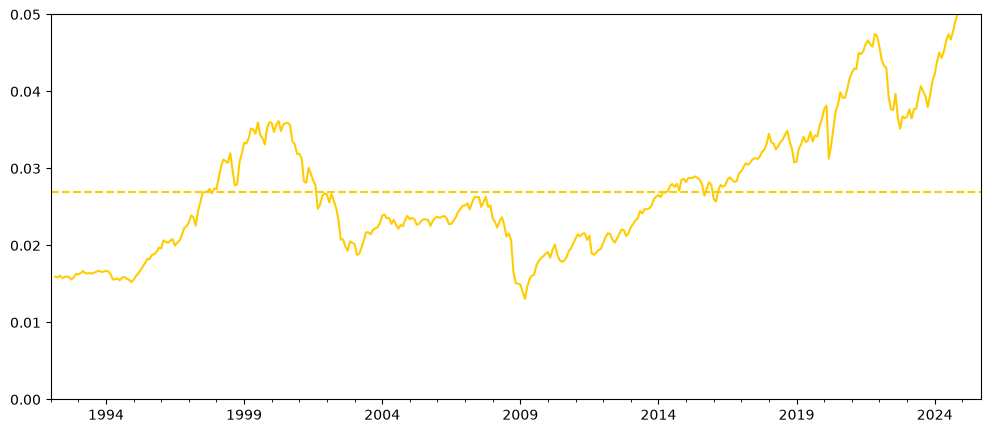

In [106]:
(df['SP500 ID2']/df['GDP'].rolling(window=4, min_periods=4, center=True).sum()).plot(color=color3)
plt.axhline((df['SP500 ID2']/df['GDP'].rolling(window=4, min_periods=4, center=True).sum()).mean(), color=color3, ls='--')
plt.ylim([0,0.05])

In [107]:
0.025 * df['GDP'].rolling(window=4, min_periods=4, center=True).sum().dropna().iloc[-1]

np.float64(2955.4462437500006)

#### Gold

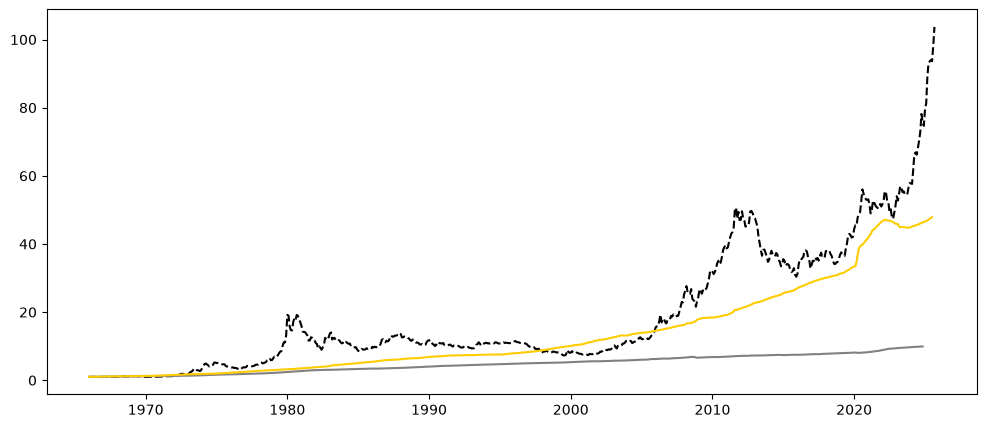

In [108]:
plt.plot(short_df['gold']/short_df['gold'].iloc[0], color=color1, linestyle='--')
plt.plot(short_df['Consumer Price Index']/short_df['Consumer Price Index'].iloc[0], color=color2)
plt.plot(short_df['M2SL']/short_df['M2SL'].iloc[0], color=color3)

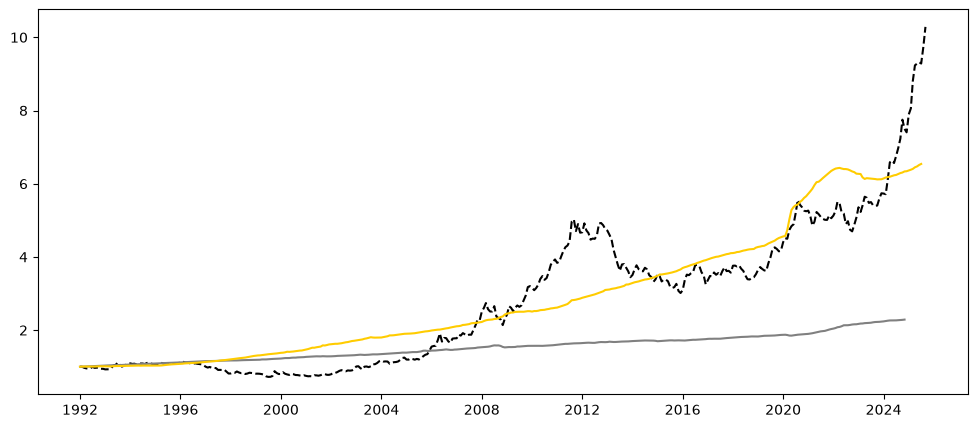

In [109]:
plt.plot(df['gold']/df['gold'].iloc[0], color=color1, linestyle='--')
plt.plot(df['Consumer Price Index']/df['Consumer Price Index'].iloc[0], color=color2)
plt.plot(df['M2SL']/df['M2SL'].iloc[0], color=color3)

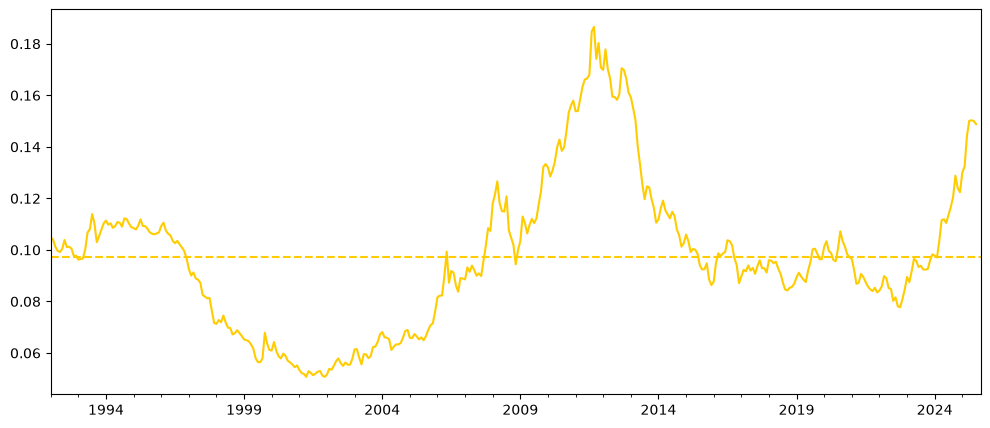

In [110]:
(df['gold']/df['M2SL']).plot(color=color3)
plt.axhline((df['gold']/df['M2SL']).mean(), color=color3, ls='--')

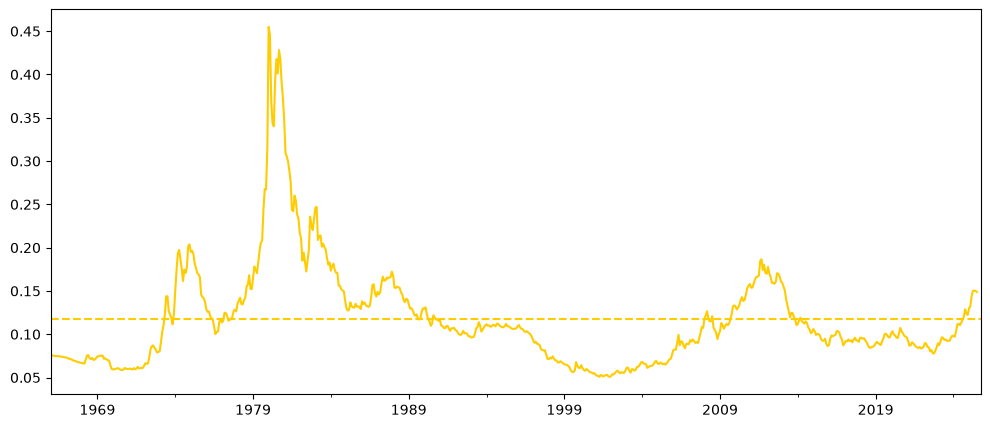

In [111]:
(short_df['gold']/short_df['M2SL']).plot(color=color3)
plt.axhline((short_df['gold']/short_df['M2SL']).mean(), color=color3, ls='--')

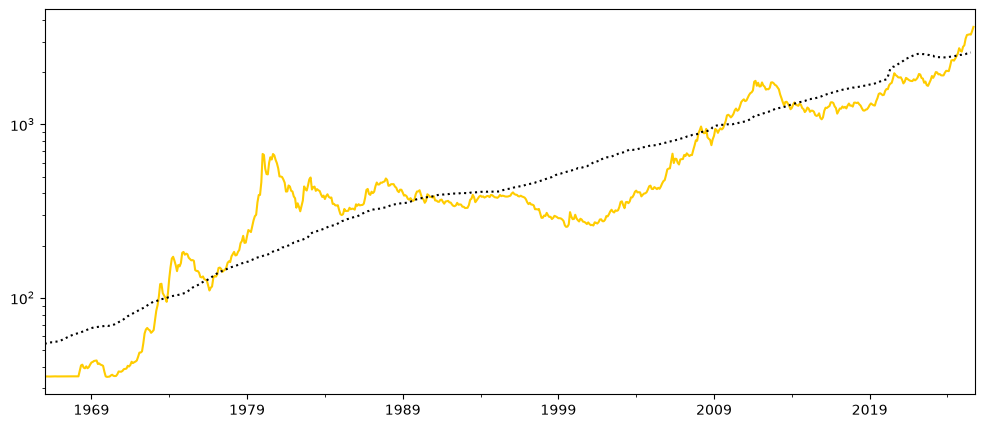

In [112]:
short_df['gold'].plot(color=color3)
((short_df['gold']/short_df['M2SL']).mean() * short_df['M2SL']).plot(color=color1, linestyle=':')
plt.yscale('log')

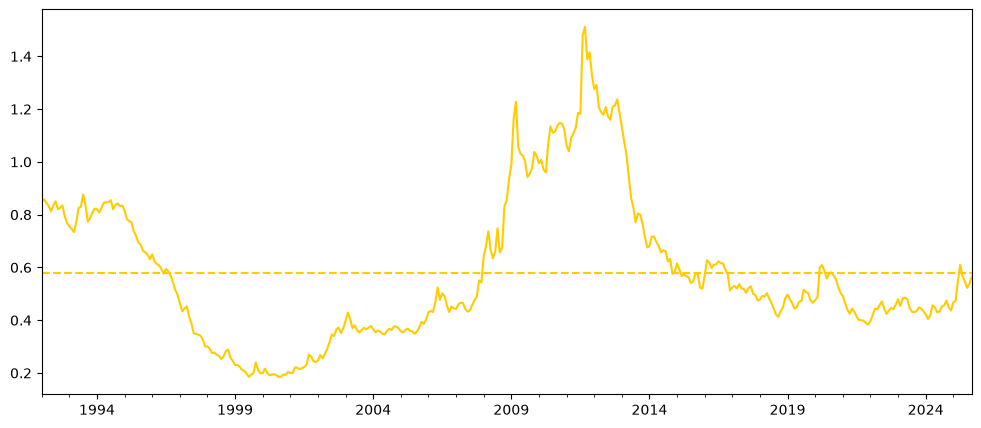

In [113]:
(df['gold']/df['SP500 ID2']).plot(color=color3)
plt.axhline((df['gold']/df['SP500 ID2']).mean(), color=color3, ls='--')

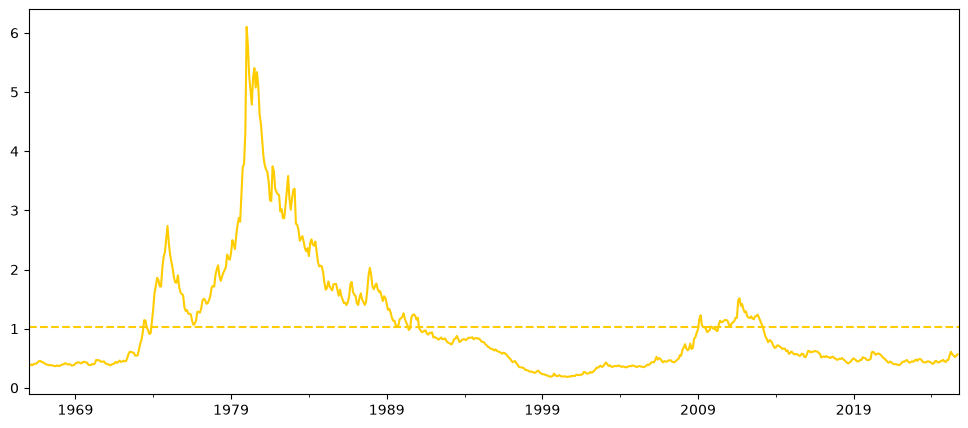

In [114]:
(short_df['gold']/short_df['SP500 ID2']).plot(color=color3)
plt.axhline((short_df['gold']/short_df['SP500 ID2']).mean(), color=color3, ls='--')

#### Gold vs M2 returns

np.float64(0.005444297619347272)

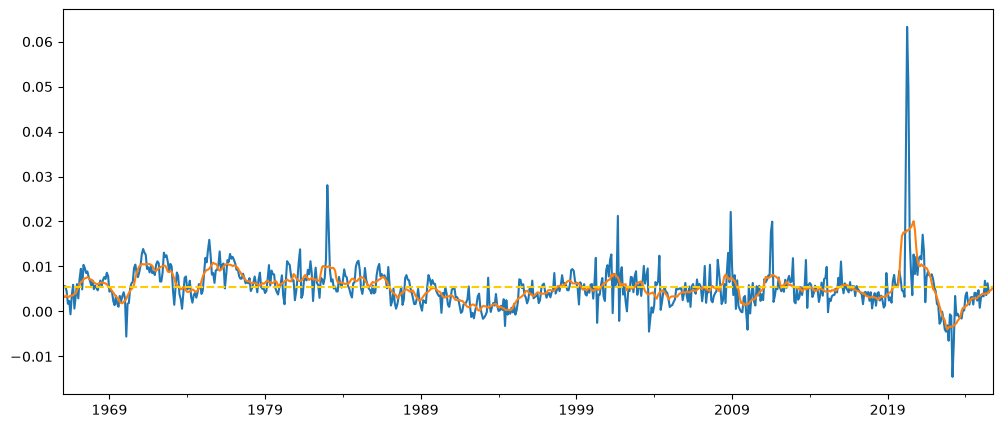

In [115]:
s1 = short_df['M2SL'].pct_change(fill_method=None)
s1.plot()
(s1.rolling(window=12, min_periods=1, center=True).mean()).plot()
plt.axhline(s1.mean(), color=color3, ls='--')
s1.mean()
# 12 * s1.mean()
# np.exp(12*np.log(1 + s1.mean()))

np.float64(0.06819673876178448)

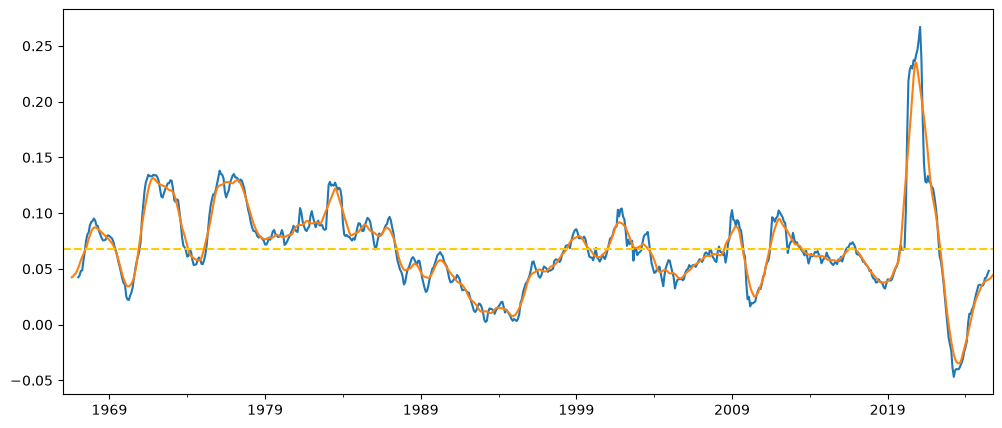

In [116]:
s1 = short_df['M2SL'].pct_change(periods=12, fill_method=None)
s1.plot()
(s1.rolling(window=12, min_periods=1, center=True).mean()).plot()
plt.axhline(s1.mean(), color=color3, ls='--')
s1.mean()

0.06819673876178448
0.10467215267820422
0.001594328523191355
0.06804968507434797


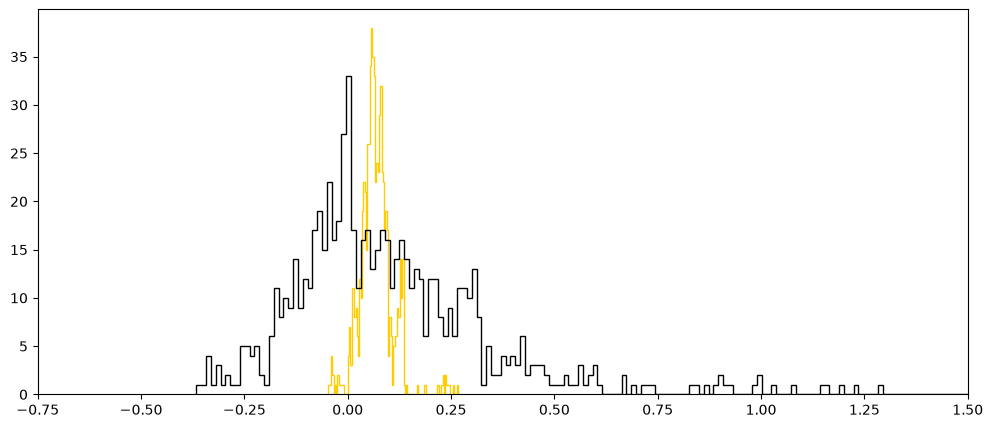

In [117]:
s1 = short_df['M2SL'].pct_change(periods=12, fill_method=None)
s2 = short_df['gold'].pct_change(periods=12, fill_method=None)

plt.hist(s1, bins=100, histtype='step', color=color3);
plt.hist(s2, bins=200, histtype='step', color=color1);

plt.xlim([-0.75,1.5])

print(s1.mean())
print(s2.mean())

print(s1.var())
print(s2.var())

#### Real Estate

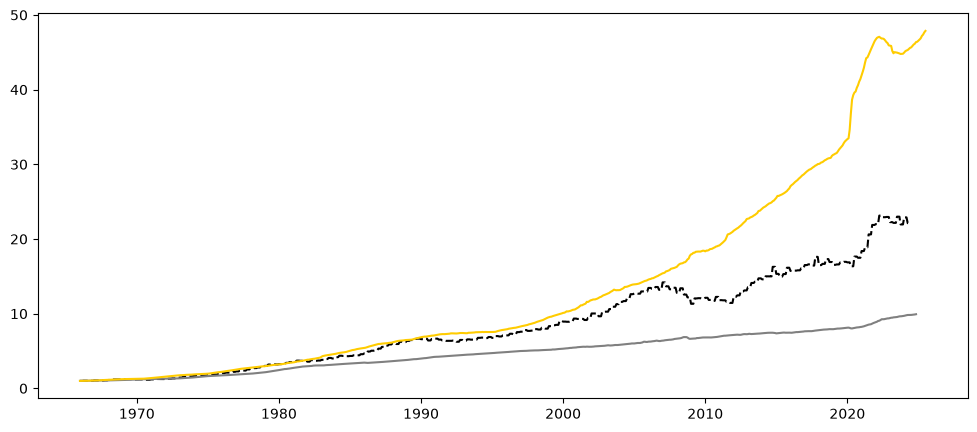

In [118]:
plt.plot(short_df['Average Sales Price of Houses Sold']/short_df['Average Sales Price of Houses Sold'].iloc[0], color=color1, linestyle='--')
plt.plot(short_df['Consumer Price Index']/short_df['Consumer Price Index'].iloc[0], color=color2)
plt.plot(short_df['M2SL']/short_df['M2SL'].iloc[0], color=color3)

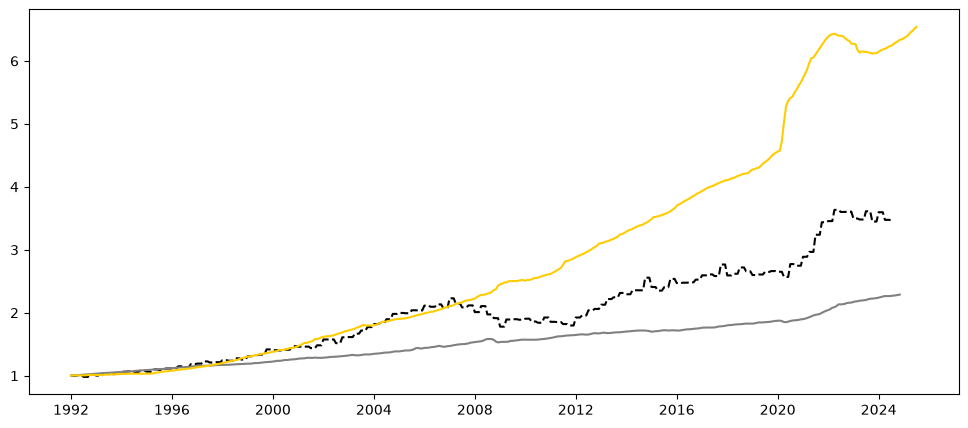

In [119]:
plt.plot(df['Average Sales Price of Houses Sold']/df['Average Sales Price of Houses Sold'].iloc[0], color=color1, linestyle='--')
plt.plot(df['Consumer Price Index']/df['Consumer Price Index'].iloc[0], color=color2)
plt.plot(df['M2SL']/df['M2SL'].iloc[0], color=color3)

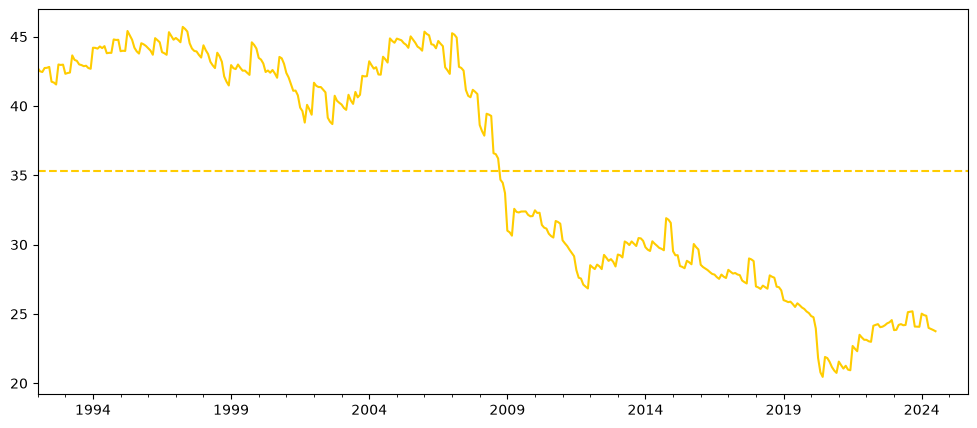

In [120]:
(df['Average Sales Price of Houses Sold']/df['M2SL']).plot(color=color3)
plt.axhline((df['Average Sales Price of Houses Sold']/df['M2SL']).mean(), color=color3, ls='--')

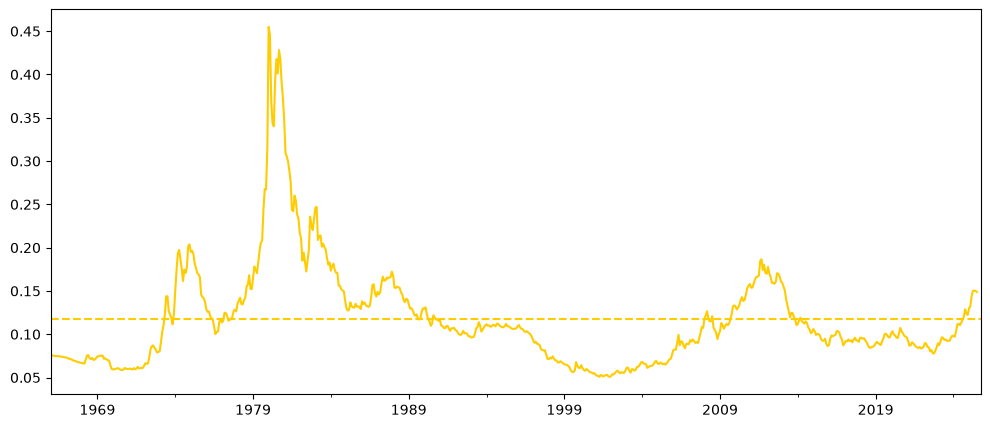

In [121]:
(short_df['gold']/short_df['M2SL']).plot(color=color3)
plt.axhline((short_df['gold']/short_df['M2SL']).mean(), color=color3, ls='--')

#### All - comparison

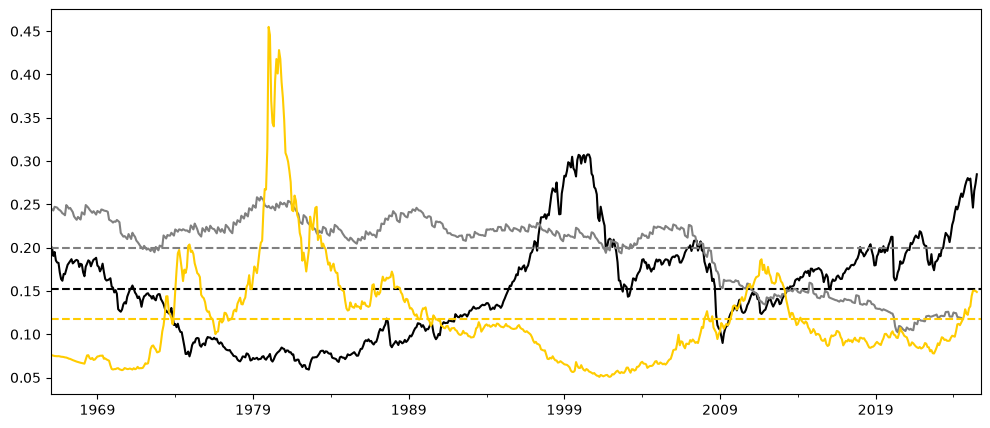

In [122]:
(short_df['SP500 ID2']/short_df['M2SL']).plot(color=color1)
plt.axhline((short_df['SP500 ID2']/short_df['M2SL']).mean(), color=color1, ls='--')

(1/200 * short_df['Average Sales Price of Houses Sold']/short_df['M2SL']).plot(color=color2)
plt.axhline(1/200 * (short_df['Average Sales Price of Houses Sold']/short_df['M2SL']).mean(), color=color2, ls='--')

(short_df['gold']/short_df['M2SL']).plot(color=color3)
plt.axhline((short_df['gold']/short_df['M2SL']).mean(), color=color3, ls='--')
# plt.xlim(['01'])

(264.0, 661.0)

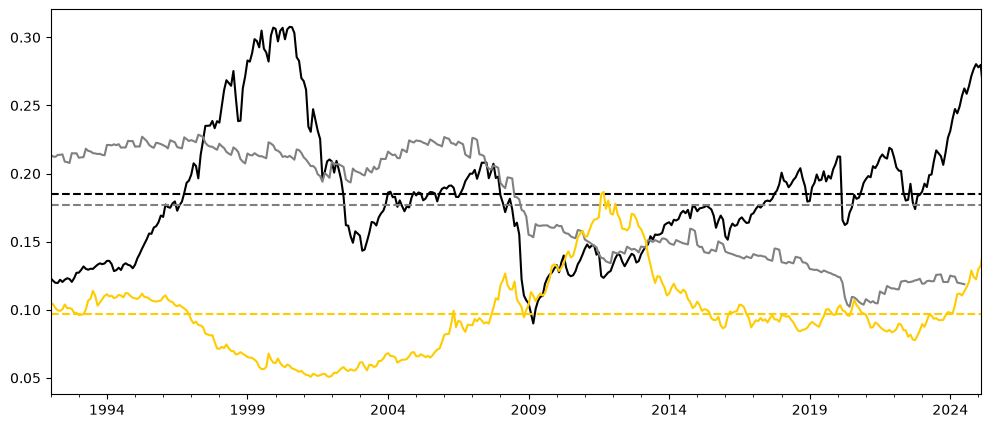

In [123]:
(df['SP500 ID2']/df['M2SL']).plot(color=color1)
plt.axhline((df['SP500 ID2']/df['M2SL']).mean(), color=color1, ls='--')

(1/200 * df['Average Sales Price of Houses Sold']/df['M2SL']).plot(color=color2)
plt.axhline(1/200 * (df['Average Sales Price of Houses Sold']/df['M2SL']).mean(), color=color2, ls='--')

(df['gold']/df['M2SL']).plot(color=color3)
plt.axhline((df['gold']/df['M2SL']).mean(), color=color3, ls='--')
plt.xlim([datetime(1992,1,1), datetime(2025,2,1)])

#### Diff

0.005444297619347272
0.004577398682080851


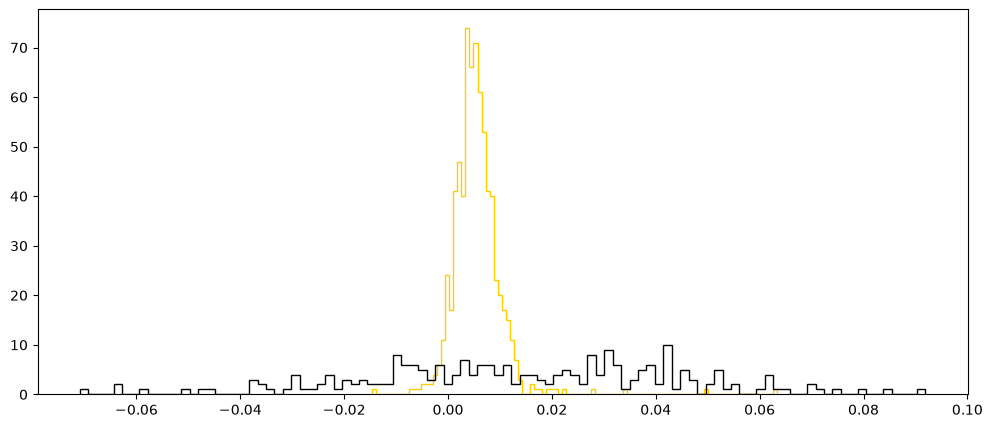

In [124]:
s1 = short_df['M2SL'].pct_change(fill_method=None)
s2 = short_df['Average Sales Price of Houses Sold'].pct_change(fill_method=None)

plt.hist(s1, bins=100, histtype='step', color=color3);
plt.hist(s2.replace(0, np.nan), bins=100, histtype='step', color=color1);

print(s1.mean())
print(s2.mean())

#### GDP vs M2

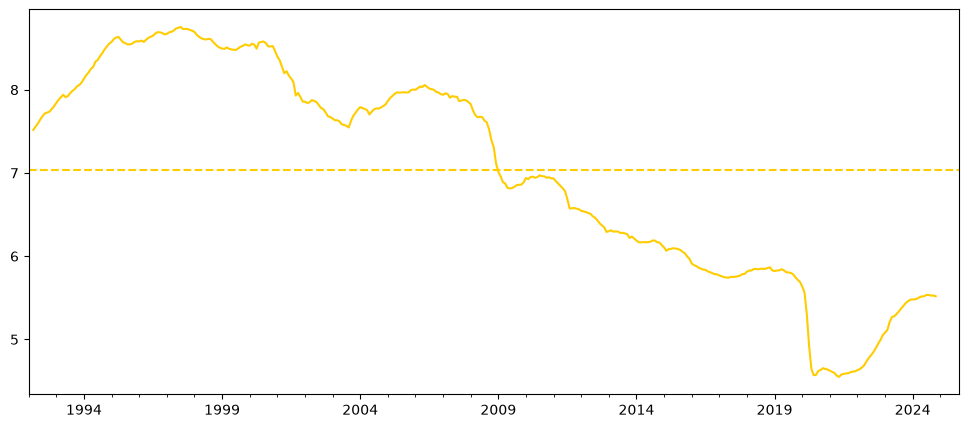

In [125]:
(df['GDP'].rolling(window=4, min_periods=4, center=True).sum()/df['M2SL']).plot(color=color3)
plt.axhline((df['GDP'].rolling(window=4, min_periods=4, center=True).sum()/df['M2SL']).mean(), color=color3, ls='--')

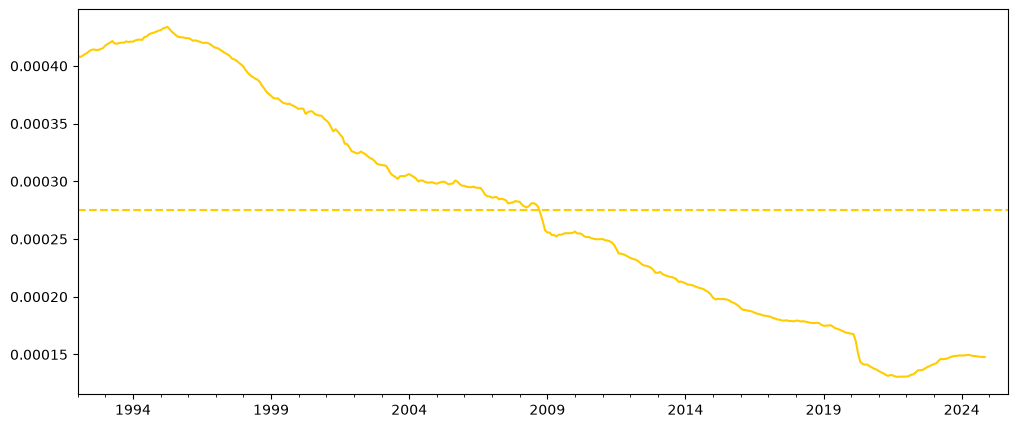

In [126]:
(df['Consumer Price Index']/df['M2SL']).plot(color=color3)
plt.axhline((df['Consumer Price Index']/df['M2SL']).mean(), color=color3, ls='--')

#### All 2

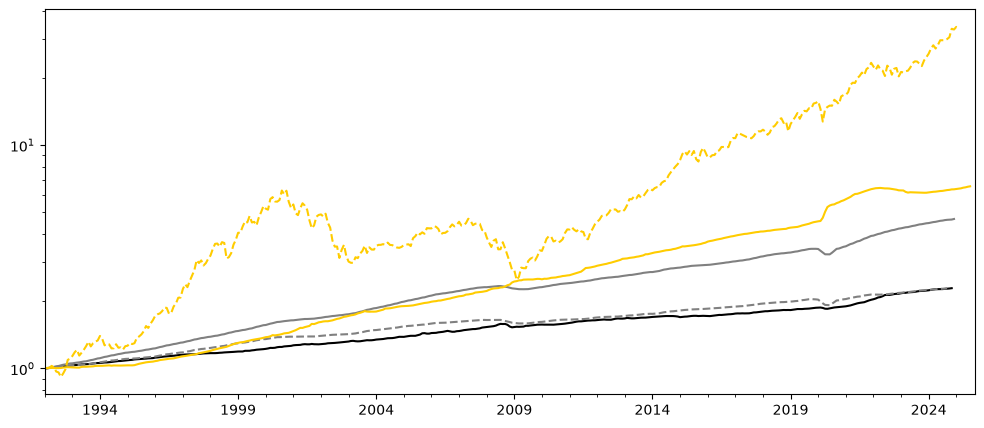

In [127]:
(df['Consumer Price Index']/df['Consumer Price Index'].iloc[0]).plot(color=color1)
(df['GDP']/df['GDP'].iloc[0]).plot(color=color2)
(df['GDP_infl_adj']/df['GDP_infl_adj'].iloc[0]).plot(color=color2, linestyle='--')
(df['M2SL']/df['M2SL'].iloc[0]).plot(color=color3)
(df['SP500']/df['SP500'].iloc[1]).plot(color=color3, linestyle='--')
plt.yscale('log')

In [128]:
print((df['M2SL'].dropna().iloc[-1] / df['M2SL'][df['M2SL'].index.year == 2000].mean())**(1/25))
print((df['SP500'].dropna().iloc[-1] / df['SP500'][df['SP500'].index.year == 2000].mean())**(1/25))

1.06308190716732
1.0733781468166121
